# 05. VISUALIZACIÓN Y COMUNICACIÓN DE RESULTADOS DEL SISTEMA DE ALERTA TEMPRANA

Este notebook desarrolla la fase de visualización y comunicación de resultados del TFM a partir de los productos analíticos generados y persistidos durante las etapas anteriores. El objetivo es transformar la evidencia obtenida sobre el comportamiento del sistema de alerta temprana en representaciones visuales que permitan interpretar de forma clara su capacidad para identificar vuelos con riesgo elevado de sufrir un retraso igual o superior a 15 minutos, así como las principales limitaciones asociadas a su utilización.

El análisis se realizará exclusivamente sobre resultados previamente obtenidos, sin introducir nuevas decisiones de modelado. El modelo definitivo, el procedimiento de preprocesamiento y el threshold de decisión permanecerán inalterados, de forma que las visualizaciones correspondientes al período externo comprendido entre enero y mayo de 2026 mantengan una función exclusivamente descriptiva y comunicativa. En consecuencia, ninguna evidencia obtenida durante esta fase se utilizará para modificar la configuración predictiva seleccionada.

La comunicación de los resultados considerará conjuntamente la capacidad de detección y el coste operativo asociado a la generación de alertas. El sistema consiguió identificar el 79.94 % de los retrasos observados durante el período externo, pero para alcanzar esta cobertura clasificó como alerta el 66.98 % de los vuelos analizados. Además, el 74.73 % de las alertas emitidas correspondieron a falsas alertas, lo que constituye una limitación relevante para interpretar el sistema como un predictor individual de alta certeza. Por este motivo, las visualizaciones deberán representar conjuntamente cobertura, precisión, falsas alertas y volumen de alertas, evitando interpretaciones sustentadas en una única métrica.

La dimensión temporal permitirá analizar si el comportamiento agregado del sistema se mantiene homogéneo entre los diferentes meses del período externo. De forma complementaria, las dimensiones operacionales permitirán representar las diferencias observadas entre franjas horarias programadas, aerolíneas y aeropuertos, prestando especial atención a la distribución de las falsas alertas y de los retrasos que no fueron detectados. Estas comparaciones tendrán un carácter descriptivo y no se utilizarán para establecer relaciones causales entre las características operacionales y el rendimiento del sistema.

Debido a que los indicadores necesarios fueron calculados y persistidos previamente, no será necesario procesar nuevamente los 3,102,447 vuelos individuales del período externo. Se utilizarán productos agregados con granularidades específicas para indicadores globales, meses, franjas horarias, aerolíneas, aeropuertos y concentración de errores. Esta estrategia reduce el coste computacional, evita cálculos redundantes y mantiene una separación explícita entre la generación de evidencia analítica y su posterior representación visual.

Las visualizaciones se diseñarán considerando tanto su utilidad académica como su posterior explotación en Tableau. Cada representación deberá responder a una pregunta analítica concreta y preservar información suficiente sobre el volumen de observaciones para evitar comparaciones basadas exclusivamente en tasas. Se priorizarán gráficos capaces de comunicar el equilibrio entre cobertura y selectividad, la variabilidad temporal del comportamiento del sistema y la concentración operacional y geográfica de los errores.

El proceso comenzará con la recuperación y validación de los productos de visualización preparados previamente. Posteriormente se definirá la estrategia de comunicación, se desarrollarán las representaciones globales, temporales, operacionales y geográficas y se establecerá la arquitectura del dashboard. Finalmente, se seleccionarán las figuras con mayor capacidad explicativa para su incorporación al documento y a la presentación final del TFM.

De esta forma, el notebook mantiene una separación explícita entre evaluación predictiva, análisis operativo y comunicación visual, utilizando las visualizaciones como mecanismo de síntesis e interpretación de resultados ya consolidados y no como una nueva etapa de selección o ajuste del sistema.

## 1. Configuración y recuperación de productos de visualización

El inicio de la fase de visualización requiere establecer un entorno reproducible desde el que recuperar los productos analíticos generados durante el análisis operativo. Esta separación permite reutilizar resultados ya consolidados y evita procesar nuevamente el dataset individual del período externo cuando los indicadores necesarios se encuentran disponibles a la granularidad adecuada.

Las rutas del proyecto proporcionarán acceso a los productos persistidos correspondientes a los indicadores globales, temporales, por franja horaria, por aerolínea, por aeropuerto y de concentración de errores. Cada uno de estos productos conserva una granularidad específica y responde a una dimensión diferente del comportamiento del sistema de alerta temprana, por lo que se mantendrán como estructuras independientes durante su recuperación.

Antes de iniciar la construcción de visualizaciones se comprobará de forma consolidada que todos los productos necesarios se encuentran disponibles y que su estructura coincide con la definida durante el análisis operativo. Se verificarán aspectos como la existencia de los archivos, el número esperado de observaciones, la disponibilidad de las variables necesarias y la coherencia de las granularidades utilizadas.

Estas comprobaciones son necesarias porque las visualizaciones posteriores dependerán directamente de estos productos. Una inconsistencia en su recuperación podría producir representaciones incompletas o comparaciones entre niveles de agregación incompatibles.

Este bloque tiene exclusivamente una función de configuración, recuperación y validación. No se calcularán nuevos indicadores ni se modificarán los resultados obtenidos durante el análisis operativo.

En este bloque se abordarán progresivamente:

1. Configuración del entorno y rutas de visualización.
2. Recuperación de los productos analíticos persistidos.
3. Validación consolidada de los productos de entrada.

Como resultado se dispondrá de un conjunto validado de productos de visualización sobre el que desarrollar las representaciones globales, temporales, operacionales y geográficas del sistema de alerta temprana.

### 1.1 Configuración del entorno y rutas de visualización

La construcción de las visualizaciones requiere establecer inicialmente las rutas desde las que se recuperarán los productos analíticos generados durante el análisis operativo. Estos productos constituyen la fuente de información del presente notebook y permiten trabajar directamente con indicadores previamente consolidados, evitando repetir operaciones sobre el dataset individual del período externo.

Se definirá la ruta raíz del proyecto y, a partir de ella, la ubicación correspondiente a los resultados del análisis operativo y al directorio específico que contiene los productos preparados para visualización. Esta organización mantiene la continuidad entre las distintas fases del TFM y permite conservar una separación clara entre los resultados analíticos originales y los productos destinados a su representación.

También se importarán únicamente las librerías necesarias para la recuperación, manipulación y posterior representación de los datos. Las herramientas específicas de visualización se incorporarán progresivamente cuando sean necesarias, evitando ampliar innecesariamente las dependencias del entorno en esta etapa inicial.

Como resultado se dispondrá de una configuración centralizada de rutas que será reutilizada durante el resto del notebook para recuperar y gestionar los productos de visualización.

In [1]:
# ---------------------------------------------------------
# 1. Importación de librerías generales
# ---------------------------------------------------------

from pathlib import Path

import numpy as np
import pandas as pd


# ---------------------------------------------------------
# 2. Configuración de la ruta raíz del proyecto
# ---------------------------------------------------------

project_root = Path(r"G:\My Drive\MASTER Big Data\TFM")


# ---------------------------------------------------------
# 3. Definición de las rutas de resultados
# ---------------------------------------------------------

results_path = project_root / "results"

operational_results_path = (
    results_path
    / "operational_analysis"
)

visualization_results_path = (
    operational_results_path
    / "visualization"
)


# ---------------------------------------------------------
# 4. Definición de los productos de visualización
# ---------------------------------------------------------

visualization_product_paths = {
    "global": visualization_results_path / "global_indicators_2026.parquet",
    "temporal": visualization_results_path / "temporal_indicators_2026.parquet",
    "time_block": visualization_results_path / "time_block_indicators_2026.parquet",
    "carrier": visualization_results_path / "carrier_indicators_2026.parquet",
    "airport": visualization_results_path / "airport_indicators_2026.parquet",
    "error_concentration": visualization_results_path / "error_concentration_2026.parquet",
}

visualization_inventory_path = (
    visualization_results_path
    / "tableau_product_inventory_2026.parquet"
)


# ---------------------------------------------------------
# 5. Resumen de la configuración
# ---------------------------------------------------------

configuration_summary = pd.DataFrame(
    {
        "element": [
            "Raíz del proyecto",
            "Resultados",
            "Análisis operativo",
            "Productos de visualización",
            "Inventario de productos",
        ],
        "path": [
            project_root,
            results_path,
            operational_results_path,
            visualization_results_path,
            visualization_inventory_path,
        ],
    }
)

configuration_summary

,element,path
0,Raíz del proyecto,G:\My Drive\MASTER Big Data\TFM
1,Resultados,G:\My Drive\MASTER Big Data\TFM\results
2,Análisis operativo,G:\My Drive\MASTER Big Data\TFM\results\operat...
3,Productos de visualización,G:\My Drive\MASTER Big Data\TFM\results\operat...
4,Inventario de productos,G:\My Drive\MASTER Big Data\TFM\results\operat...


### 1.2 Recuperación de los productos analíticos persistidos

Una vez configuradas las rutas del entorno, se recuperarán los productos analíticos preparados durante el análisis operativo para su utilización directa en la fase de visualización. Estos productos contienen los indicadores previamente calculados y organizados según la granularidad necesaria para representar las distintas dimensiones del comportamiento del sistema de alerta temprana.

La recuperación comprenderá los indicadores globales, la evolución temporal mensual, el comportamiento por franja horaria, las diferencias entre aerolíneas, la información correspondiente a los aeropuertos de origen y destino y la concentración de falsas alertas y retrasos no detectados. También se recuperará el inventario generado previamente, que documenta la granularidad y el número de observaciones de cada producto.

Los productos se mantendrán como estructuras independientes, ya que representan niveles de agregación diferentes. Esta decisión evita combinaciones artificiales entre granularidades incompatibles y facilita que cada visualización posterior utilice exclusivamente la fuente correspondiente a la pregunta analítica que pretende responder.

En esta etapa no se recalcularán métricas ni se realizarán transformaciones sobre los indicadores recuperados. El objetivo consiste únicamente en materializar en memoria los productos persistidos y obtener una descripción básica de su estructura antes de realizar su validación consolidada.

Como resultado se dispondrá de los datasets analíticos necesarios para desarrollar las visualizaciones globales, temporales, operacionales y geográficas del sistema.

In [2]:
# ---------------------------------------------------------
# 1. Recuperación de los productos de visualización
# ---------------------------------------------------------

global_visualization = pd.read_parquet(
    visualization_product_paths["global"]
)

temporal_visualization = pd.read_parquet(
    visualization_product_paths["temporal"]
)

time_block_visualization = pd.read_parquet(
    visualization_product_paths["time_block"]
)

carrier_visualization = pd.read_parquet(
    visualization_product_paths["carrier"]
)

airport_visualization = pd.read_parquet(
    visualization_product_paths["airport"]
)

error_concentration_visualization = pd.read_parquet(
    visualization_product_paths["error_concentration"]
)


# ---------------------------------------------------------
# 2. Recuperación del inventario de productos
# ---------------------------------------------------------

visualization_inventory = pd.read_parquet(
    visualization_inventory_path
)


# ---------------------------------------------------------
# 3. Consolidación de los productos recuperados
# ---------------------------------------------------------

visualization_products = {
    "global": global_visualization,
    "temporal": temporal_visualization,
    "time_block": time_block_visualization,
    "carrier": carrier_visualization,
    "airport": airport_visualization,
    "error_concentration": error_concentration_visualization,
}


# ---------------------------------------------------------
# 4. Resumen estructural de los productos recuperados
# ---------------------------------------------------------

recovery_summary = pd.DataFrame(
    [
        {
            "product": product_name,
            "rows": len(product_data),
            "columns": product_data.shape[1],
            "memory_mb": product_data.memory_usage(
                deep=True
            ).sum() / (1024 ** 2),
        }
        for product_name, product_data in visualization_products.items()
    ]
)

recovery_summary

,product,rows,columns,memory_mb
0,global,12,5,0.003748
1,temporal,5,22,0.001447
2,time_block,19,16,0.004656
3,carrier,19,16,0.005145
4,airport,730,16,0.168254
5,error_concentration,403,7,0.068551


### 1.3 Validación consolidada de los productos de entrada

Antes de iniciar el diseño y construcción de las visualizaciones se realizará una validación consolidada de los productos recuperados. El objetivo es comprobar que las estructuras disponibles reproducen las granularidades y variables definidas durante su preparación y que pueden utilizarse como fuentes consistentes durante el resto del notebook.

La validación comprobará la disponibilidad de los archivos persistidos, las dimensiones esperadas de cada producto y la presencia de las variables esenciales para su posterior explotación. También se verificará la coherencia de las granularidades principales, incluyendo los cinco meses del período externo, las franjas horarias, las aerolíneas y la diferenciación entre aeropuertos de origen y destino.

Adicionalmente, se contrastará el número de observaciones recuperadas con el inventario de productos persistido. Esta comprobación proporciona trazabilidad entre la preparación realizada en el análisis operativo y los datasets que serán utilizados durante la fase de visualización.

La validación se realizará de forma consolidada para evitar repetir comprobaciones estructurales en los bloques posteriores. Una vez confirmada la consistencia de los productos, las siguientes etapas podrán concentrarse exclusivamente en el diseño y comunicación visual de los resultados.

Como resultado se dispondrá de una confirmación explícita de que los productos de entrada son compatibles con la estructura prevista para el desarrollo del notebook.

In [3]:
# ---------------------------------------------------------
# 1. Definición de las dimensiones esperadas
# ---------------------------------------------------------

expected_shapes = {
    "global": (12, 5),
    "temporal": (5, 22),
    "time_block": (19, 16),
    "carrier": (19, 16),
    "airport": (730, 16),
    "error_concentration": (403, 7),
}


# ---------------------------------------------------------
# 2. Definición de las variables esenciales
# ---------------------------------------------------------

required_columns = {
    "global": {
        "analysis_level",
        "analysis_period",
        "dimension",
        "indicator",
        "value",
    },
    "temporal": {
        "analysis_level",
        "analysis_month",
        "flights",
        "observed_delays",
        "alerts",
        "observed_delay_rate",
        "alert_rate",
        "recall",
        "precision",
        "false_alert_share",
        "mean_score",
    },
    "time_block": {
        "analysis_dimension",
        "DEP_TIME_BLK",
        "flights",
        "observed_delays",
        "alerts",
        "alert_rate",
        "recall",
        "precision",
        "false_alert_share",
        "alert_delay_lift",
        "time_block_order",
    },
    "carrier": {
        "analysis_dimension",
        "OP_UNIQUE_CARRIER",
        "flights",
        "population_share",
        "observed_delays",
        "alerts",
        "alert_rate",
        "recall",
        "precision",
        "false_alert_share",
        "alert_delay_lift",
    },
    "airport": {
        "airport_role",
        "airport",
        "flights",
        "population_share",
        "observed_delays",
        "alerts",
        "alert_rate",
        "recall",
        "precision",
        "false_alert_share",
        "alert_delay_lift",
    },
    "error_concentration": {
        "dimension",
        "category",
        "category_order",
        "FP",
        "FN",
        "fp_share",
        "fn_share",
    },
}


# ---------------------------------------------------------
# 3. Validación individual de los productos
# ---------------------------------------------------------

validation_records = []

for product_name, product_data in visualization_products.items():

    expected_rows, expected_columns = expected_shapes[product_name]

    validation_records.append(
        {
            "product": product_name,
            "file_exists": visualization_product_paths[
                product_name
            ].exists(),
            "rows_valid": len(product_data) == expected_rows,
            "columns_count_valid": (
                product_data.shape[1] == expected_columns
            ),
            "required_columns_valid": required_columns[
                product_name
            ].issubset(product_data.columns),
        }
    )

product_validation = pd.DataFrame(validation_records)


# ---------------------------------------------------------
# 4. Validación de las granularidades principales
# ---------------------------------------------------------

temporal_granularity_valid = (
    temporal_visualization["analysis_month"].nunique() == 5
)

time_block_granularity_valid = (
    time_block_visualization["DEP_TIME_BLK"].nunique() == 19
)

carrier_granularity_valid = (
    carrier_visualization["OP_UNIQUE_CARRIER"].nunique() == 19
)

airport_role_counts = (
    airport_visualization
    .groupby("airport_role", observed=True)
    .size()
)

airport_granularity_valid = (
    len(airport_role_counts) == 2
    and sorted(airport_role_counts.tolist()) == [365, 365]
)

error_dimension_valid = (
    error_concentration_visualization["dimension"].nunique() == 3
)


# ---------------------------------------------------------
# 5. Validación del inventario persistido
# ---------------------------------------------------------

inventory_rows_valid = (
    len(visualization_inventory)
    == len(visualization_products)
)

inventory_product_rows_valid = (
    sorted(visualization_inventory["rows"].tolist())
    == sorted(
        len(product_data)
        for product_data in visualization_products.values()
    )
)


# ---------------------------------------------------------
# 6. Consolidación de la validación
# ---------------------------------------------------------

granularity_validation = pd.DataFrame(
    {
        "validation": [
            "Cinco meses del período externo",
            "Diecinueve franjas horarias",
            "Diecinueve aerolíneas",
            "Aeropuertos de origen y destino",
            "Tres dimensiones de concentración de errores",
            "Número de productos del inventario",
            "Filas coherentes con el inventario",
        ],
        "valid": [
            temporal_granularity_valid,
            time_block_granularity_valid,
            carrier_granularity_valid,
            airport_granularity_valid,
            error_dimension_valid,
            inventory_rows_valid,
            inventory_product_rows_valid,
        ],
    }
)

visualization_inputs_valid = (
    product_validation[
        [
            "file_exists",
            "rows_valid",
            "columns_count_valid",
            "required_columns_valid",
        ]
    ]
    .to_numpy()
    .all()
    and granularity_validation["valid"].all()
)


# ---------------------------------------------------------
# 7. Presentación de los resultados
# ---------------------------------------------------------

print("Validación de productos")
display(product_validation)

print("\nValidación de granularidades e inventario")
display(granularity_validation)

print(
    "\nValidación consolidada de los productos de entrada:",
    visualization_inputs_valid,
)

Validación de productos


,product,file_exists,rows_valid,columns_count_valid,required_columns_valid
0,global,True,True,True,True
1,temporal,True,True,True,True
2,time_block,True,True,True,True
3,carrier,True,True,True,True
4,airport,True,True,True,True
5,error_concentration,True,True,True,True



Validación de granularidades e inventario


,validation,valid
0,Cinco meses del período externo,True
1,Diecinueve franjas horarias,True
2,Diecinueve aerolíneas,True
3,Aeropuertos de origen y destino,True
4,Tres dimensiones de concentración de errores,True
5,Número de productos del inventario,True
6,Filas coherentes con el inventario,True



Validación consolidada de los productos de entrada: True


#### Interpretación

La validación consolidada confirma que los seis productos de visualización están disponibles, presentan las dimensiones esperadas y contienen las variables esenciales necesarias para su explotación posterior.

También se verificó la coherencia de las principales granularidades analíticas: cinco meses, diecinueve franjas horarias, diecinueve aerolíneas, dos funciones aeroportuarias y tres dimensiones para la concentración de errores. El inventario persistido reproduce asimismo el número de observaciones de cada producto.

Con estas comprobaciones, los productos de entrada pueden considerarse consistentes y adecuados para continuar con la fase de diseño de la estrategia de visualización.

## 2. Diseño de la estrategia de visualización

Una vez recuperados y validados los productos analíticos, la construcción de las visualizaciones requiere definir previamente qué información debe comunicarse y qué representación resulta más adecuada para cada dimensión del análisis. Esta planificación permite evitar una selección de gráficos basada únicamente en criterios estéticos y mantener una correspondencia explícita entre las preguntas planteadas, los indicadores disponibles y la evidencia obtenida durante el análisis operativo.

La estrategia de visualización se orientará a comunicar el comportamiento del sistema de alerta temprana desde varias perspectivas complementarias. En primer lugar, será necesario representar su funcionamiento global, mostrando conjuntamente el volumen de alertas, la cobertura de los retrasos y la proporción de falsas alertas. Esta combinación resulta especialmente relevante porque una elevada capacidad de detección no implica necesariamente una elevada capacidad de discriminación individual.

En segundo lugar, se incorporará una perspectiva temporal destinada a mostrar cómo varían los principales indicadores entre enero y mayo de 2026. El objetivo será hacer visible la variabilidad observada durante el período externo sin interpretar estas diferencias como evidencia causal de estacionalidad, deterioro o drift del modelo. Las representaciones temporales deberán permitir comparar simultáneamente la intensidad de las alertas y su rendimiento operativo.

La dimensión operacional permitirá estudiar el comportamiento del sistema según las franjas horarias programadas y las aerolíneas. En estas comparaciones será necesario conservar información sobre el volumen de vuelos, ya que las tasas obtenidas en categorías con diferente representación no deben interpretarse de manera aislada. De forma complementaria, la dimensión geográfica permitirá representar los indicadores asociados a los aeropuertos de origen y destino manteniendo separadas ambas funciones operacionales.

También se prestará atención específica a la distribución de los errores. Las falsas alertas y los retrasos no detectados representan consecuencias operativas diferentes y, por tanto, deberán visualizarse de forma que sea posible identificar dónde se concentra cada tipo de error sin confundir concentración absoluta con peor rendimiento relativo.

La selección de las representaciones tendrá en cuenta su posterior utilización en Tableau. Se priorizarán estructuras sencillas, comparables e interpretables, evitando gráficos redundantes o visualizaciones que oculten el tamaño de las poblaciones analizadas. La finalidad será construir una narrativa visual coherente con los resultados ya consolidados y facilitar posteriormente la definición del dashboard y la selección de figuras para el documento final.

Este bloque tiene una función de diseño metodológico. No pretende generar nuevos resultados sobre el sistema, sino establecer los criterios que determinarán cómo se representará la evidencia disponible en los bloques posteriores.

En este bloque se abordarán progresivamente:

1. Definición de los objetivos de comunicación.
2. Asociación entre preguntas analíticas e indicadores.
3. Selección de visualizaciones y estructura narrativa.

Como resultado se dispondrá de una estrategia de visualización explícita que vincule las principales preguntas del análisis operativo con los indicadores y representaciones que se utilizarán para comunicar sus resultados.

### 2.1 Definición de los objetivos de comunicación

La estrategia de visualización debe establecer qué aspectos del sistema de alerta temprana se pretende comunicar antes de seleccionar indicadores y representaciones gráficas. El objetivo será facilitar una interpretación conjunta de su capacidad de detección, su selectividad y las diferencias observadas entre distintos contextos.

En primer lugar, se representará el comportamiento global del sistema relacionando la cobertura de los retrasos con la tasa de alerta, la precisión y la proporción de falsas alertas. Esta lectura conjunta resulta necesaria para evitar que una elevada capacidad de detección se interprete de forma aislada como una elevada capacidad de discriminación.

En segundo lugar, se mostrará la variabilidad temporal observada entre enero y mayo de 2026, manteniendo una interpretación descriptiva y evitando atribuir las diferencias observadas a fenómenos como estacionalidad, drift o deterioro del modelo sin evidencia específica que lo sustente.

La dimensión operacional permitirá comparar el comportamiento entre franjas horarias y aerolíneas, mientras que la dimensión geográfica permitirá analizar los aeropuertos de origen y destino. En ambos casos se considerará también el volumen de observaciones para contextualizar correctamente las tasas obtenidas.

Finalmente, se representará la concentración de falsas alertas y retrasos no detectados, diferenciando ambos tipos de error por sus distintas implicaciones operativas.

Estas visualizaciones mantendrán como criterio transversal que una alerta representa un riesgo estimado elevado y no la certeza de que se produzca un retraso. La comunicación se orientará, por tanto, a presentar el sistema como una herramienta de alerta temprana y priorización de riesgo, mostrando simultáneamente su capacidad de detección y sus principales limitaciones.

### 2.2 Asociación entre preguntas analíticas e indicadores

Una vez definidos los objetivos de comunicación, es necesario establecer una correspondencia entre las preguntas analíticas, los indicadores disponibles y los productos preparados para visualización. Esta asociación permitirá seleccionar posteriormente cada gráfico a partir de una finalidad concreta.

El comportamiento global se analizará mediante el volumen de vuelos, retrasos y alertas, junto con la tasa de alerta, Recall, Precision y proporción de falsas alertas. Estos indicadores permitirán representar conjuntamente la cobertura alcanzada y el nivel de selectividad del sistema.

La perspectiva temporal utilizará las tasas mensuales de retraso y alerta, Recall, Precision, falsas alertas y distribución del score de riesgo. Su finalidad será mostrar cómo varía el comportamiento del sistema entre los cinco meses del período externo.

Para las dimensiones operacionales se utilizarán el volumen de vuelos, la tasa de alerta, Recall, Precision, falsas alertas y lift de retraso. Estos indicadores permitirán comparar franjas horarias y aerolíneas manteniendo el volumen como referencia para contextualizar las diferencias observadas.

El análisis geográfico utilizará los mismos indicadores para los aeropuertos, conservando explícitamente la distinción entre origen y destino. Finalmente, la concentración de errores se analizará mediante el número y la proporción de falsos positivos y falsos negativos dentro de cada dimensión disponible.

La relación entre preguntas, indicadores y productos queda definida de la siguiente forma:

| Pregunta analítica | Indicadores principales | Producto |
| --- | --- | --- |
| ¿Cuál es el comportamiento global del sistema? | Vuelos, retrasos, alertas, tasa de alerta, Recall, Precision y falsas alertas | Indicadores globales |
| ¿Cómo varía el sistema durante el período externo? | Tasa de retraso, tasa de alerta, Recall, Precision, falsas alertas y score | Indicadores temporales |
| ¿Cómo cambia según la franja horaria? | Volumen, tasa de alerta, Recall, Precision, falsas alertas y lift | Franjas horarias |
| ¿Existen diferencias entre aerolíneas? | Volumen, tasa de alerta, Recall, Precision, falsas alertas y lift | Aerolíneas |
| ¿Cómo se distribuye el comportamiento entre aeropuertos? | Volumen, tasa de alerta, Recall, Precision, falsas alertas y lift | Aeropuertos |
| ¿Dónde se concentran los principales errores? | FP, FN, proporción de FP y proporción de FN | Concentración de errores |

Esta correspondencia proporciona una base explícita para seleccionar las representaciones gráficas y evita incorporar visualizaciones que no respondan a una pregunta relevante para la interpretación del sistema.

### 2.3 Selección de visualizaciones y estructura narrativa

La selección de las representaciones gráficas se realizará atendiendo a la naturaleza de cada indicador y a la pregunta analítica que debe responder. Se priorizarán visualizaciones sencillas que permitan comparar resultados y mantengan visible el contexto necesario para su correcta interpretación.

Los indicadores globales se presentarán mediante elementos de síntesis y gráficos que permitan relacionar cobertura, volumen de alertas y selectividad. La evolución mensual se representará principalmente mediante gráficos de líneas, adecuados para comparar el comportamiento de los indicadores a lo largo del período externo.

Las franjas horarias se representarán respetando su orden cronológico, mientras que las aerolíneas se ordenarán según el indicador relevante para cada comparación. En ambos casos se combinarán tasas y volumen cuando resulte necesario para evitar interpretar categorías sin considerar su representación en la población analizada.

Para los aeropuertos se priorizarán comparaciones que permitan identificar diferencias entre origen y destino sin intentar representar simultáneamente las 365 categorías cuando ello reduzca la legibilidad. Las visualizaciones podrán concentrarse en los aeropuertos con mayor volumen o en aquellos necesarios para responder una pregunta específica.

La concentración de falsas alertas y retrasos no detectados se representará diferenciando ambos tipos de error. Estas visualizaciones deberán interpretarse dentro de cada dimensión, ya que las distribuciones por franja horaria, aerolínea y aeropuerto constituyen perspectivas diferentes sobre los mismos errores globales.

La narrativa visual seguirá una secuencia desde la visión general hacia el detalle: comportamiento global, evolución temporal, dimensiones operacionales, dimensión geográfica y concentración de errores. Esta estructura permitirá presentar primero las características generales del sistema y profundizar posteriormente en los segmentos donde su comportamiento presenta mayores diferencias.

Las representaciones seleccionadas servirán como base para el posterior diseño del dashboard en Tableau y para identificar las figuras con mayor capacidad explicativa para el documento final del TFM.

## 3. Visualización global del sistema de alerta temprana

La primera etapa de representación se centrará en ofrecer una visión global del comportamiento del sistema durante el período externo comprendido entre enero y mayo de 2026. El objetivo es sintetizar los principales resultados de forma que puedan interpretarse conjuntamente la magnitud de la población analizada, la generación de alertas y la capacidad para identificar retrasos reales.

La representación global deberá hacer visible el equilibrio entre cobertura y selectividad. Una elevada proporción de retrasos detectados puede requerir la emisión de alertas sobre una parte considerable de los vuelos, por lo que Recall debe analizarse conjuntamente con la tasa de alerta, Precision y la proporción de falsas alertas.

También se representará la composición de las decisiones del sistema mediante los aciertos y errores asociados a las alertas. Esta perspectiva permitirá diferenciar los retrasos correctamente detectados de las falsas alertas y contextualizar la utilidad del sistema como mecanismo de alerta temprana y priorización de riesgo.

Las visualizaciones de este bloque utilizarán exclusivamente los indicadores globales ya consolidados. No se calcularán nuevas métricas ni se modificarán los resultados obtenidos durante la evaluación externa.

En este bloque se abordarán progresivamente:

1. Representación del volumen de vuelos, retrasos y alertas.
2. Visualización del equilibrio entre cobertura y selectividad.
3. Representación de la composición de las alertas.

Como resultado se dispondrá de una síntesis visual del comportamiento global del sistema que servirá como punto de partida para los análisis temporales y operacionales posteriores.

### 3.1 Representación del volumen de vuelos, retrasos y alertas

La caracterización visual del sistema comienza con la representación del volumen total de vuelos analizados, las alertas emitidas y los retrasos observados durante el período externo. Estas magnitudes proporcionan el contexto necesario para interpretar posteriormente las métricas de cobertura y selectividad.

Los tres valores no representan categorías mutuamente excluyentes, ya que los vuelos alertados y los vuelos con retraso forman parte de la población total. Por este motivo, se utilizará una comparación mediante barras independientes en lugar de una representación basada en proporciones de un mismo total.

La visualización permitirá observar la relación entre el tamaño de la población analizada, la cantidad de alertas generadas y el número de retrasos realmente registrados, ofreciendo una primera aproximación a la intensidad con la que opera el sistema de alerta temprana.

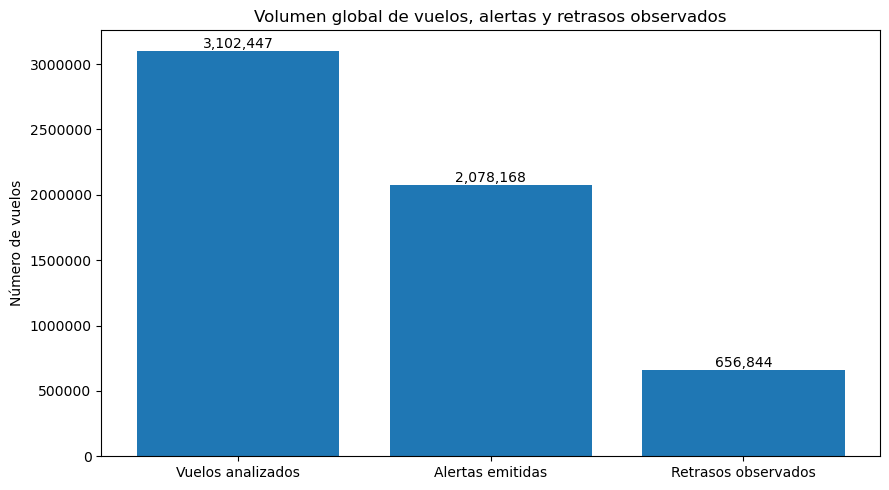

,category,flights
0,Vuelos analizados,3102447.0
1,Alertas emitidas,2078168.0
2,Retrasos observados,656844.0


In [4]:
# ---------------------------------------------------------
# 1. Recuperación de los indicadores necesarios
# ---------------------------------------------------------

global_indicator_values = (
    global_visualization
    .set_index("indicator")["value"]
)

total_flights = global_indicator_values["Vuelos analizados"]
observed_delay_rate = global_indicator_values[
    "Tasa observada de retraso"
]
alert_rate = global_indicator_values["Tasa de alerta"]

total_observed_delays = round(
    total_flights * observed_delay_rate
)

total_alerts = round(
    total_flights * alert_rate
)


# ---------------------------------------------------------
# 2. Preparación de los datos para la visualización
# ---------------------------------------------------------

global_volume_plot = pd.DataFrame(
    {
        "category": [
            "Vuelos analizados",
            "Alertas emitidas",
            "Retrasos observados",
        ],
        "flights": [
            total_flights,
            total_alerts,
            total_observed_delays,
        ],
    }
)


# ---------------------------------------------------------
# 3. Construcción de la visualización
# ---------------------------------------------------------

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    global_volume_plot["category"],
    global_volume_plot["flights"],
)

ax.set_title(
    "Volumen global de vuelos, alertas y retrasos observados"
)
ax.set_ylabel("Número de vuelos")
ax.set_xlabel("")
ax.ticklabel_format(
    style="plain",
    axis="y",
)

for bar, value in zip(
    bars,
    global_volume_plot["flights"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 4. Presentación de los valores representados
# ---------------------------------------------------------

global_volume_plot

#### Interpretación

Durante el período externo se analizaron 3,102,447 vuelos, de los cuales 656,844 registraron un retraso igual o superior a 15 minutos. El sistema emitió 2,078,168 alertas, un volumen considerablemente superior al número de retrasos observados.

Esta diferencia evidencia la elevada intensidad de alertas necesaria para alcanzar la cobertura definida por el sistema y anticipa la necesidad de analizar conjuntamente su capacidad de detección y su selectividad.

### 3.2 Visualización del equilibrio entre cobertura y selectividad

La utilidad del sistema de alerta temprana no puede evaluarse únicamente mediante la proporción de retrasos detectados. Una cobertura elevada puede alcanzarse aumentando el número de vuelos clasificados como alerta, lo que puede reducir la precisión e incrementar las falsas alertas.

Para representar este equilibrio se compararán la tasa de alerta, Recall, Precision y la proporción de falsas alertas. La visualización conjunta permitirá observar simultáneamente la capacidad de detección y el coste asociado a la selectividad del sistema.

Esta representación resulta especialmente relevante para interpretar correctamente el sistema como una herramienta de alerta temprana y priorización de riesgo, en lugar de como un predictor individual de alta certeza.

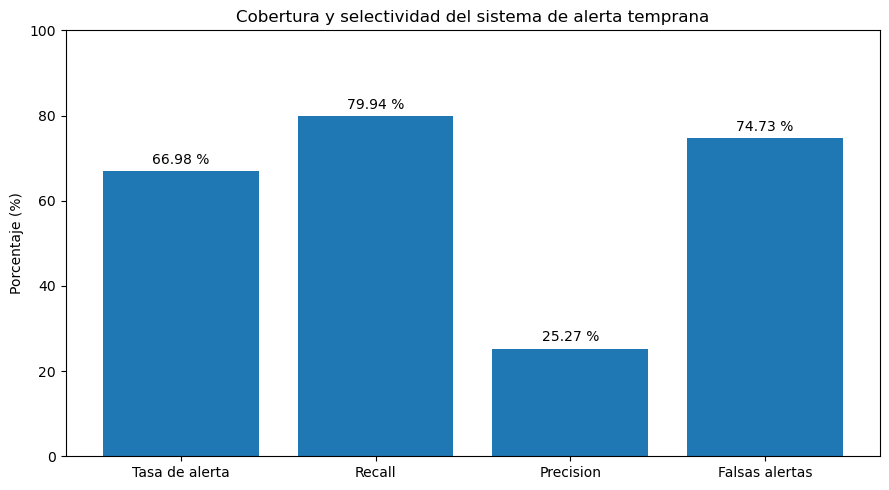

,indicator,percentage
0,Tasa de alerta,66.984803
1,Recall,79.943640
2,Precision,25.267688
3,Falsas alertas,74.732312


In [5]:
# ---------------------------------------------------------
# 1. Recuperación de los indicadores globales
# ---------------------------------------------------------

global_indicator_values = (
    global_visualization
    .set_index("indicator")["value"]
)

global_performance_plot = pd.DataFrame(
    {
        "indicator": [
            "Tasa de alerta",
            "Recall",
            "Precision",
            "Falsas alertas",
        ],
        "value": [
            global_indicator_values["Tasa de alerta"],
            global_indicator_values["Cobertura de retrasos"],
            global_indicator_values["Precisión de las alertas"],
            global_indicator_values["Proporción de falsas alertas"],
        ],
    }
)

global_performance_plot["percentage"] = (
    global_performance_plot["value"] * 100
)


# ---------------------------------------------------------
# 2. Construcción de la visualización
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    global_performance_plot["indicator"],
    global_performance_plot["percentage"],
)

ax.set_title(
    "Cobertura y selectividad del sistema de alerta temprana"
)
ax.set_ylabel("Porcentaje (%)")
ax.set_xlabel("")
ax.set_ylim(0, 100)

for bar, value in zip(
    bars,
    global_performance_plot["percentage"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f} %",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 3. Presentación de los valores representados
# ---------------------------------------------------------

global_performance_plot[
    ["indicator", "percentage"]
]

#### Interpretación

El sistema detecta el 79.94 % de los retrasos observados, aunque para alcanzar esta cobertura clasifica como alerta el 66.98 % de los vuelos analizados.

La Precision se sitúa en 25.27 % y el 74.73 % de las alertas son falsas, evidenciando una capacidad limitada de discriminación individual. Por tanto, el sistema resulta más adecuado como mecanismo de alerta temprana y priorización de riesgo que como predictor de alta certeza.

### 3.3 Representación de la composición de las alertas

La caracterización global se completa mediante la representación de los aciertos y errores asociados a las decisiones del sistema. Para ello se utilizarán las cuatro categorías de la matriz de confusión: verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos.

Esta descomposición permite identificar el volumen de retrasos correctamente anticipados, falsas alertas, vuelos correctamente no alertados y retrasos no detectados. Su representación en valores absolutos complementa las tasas analizadas previamente y permite dimensionar la magnitud real de cada resultado.

La visualización facilitará especialmente la comparación entre falsas alertas y retrasos no detectados, dos errores con implicaciones diferentes para el funcionamiento del sistema de alerta temprana.

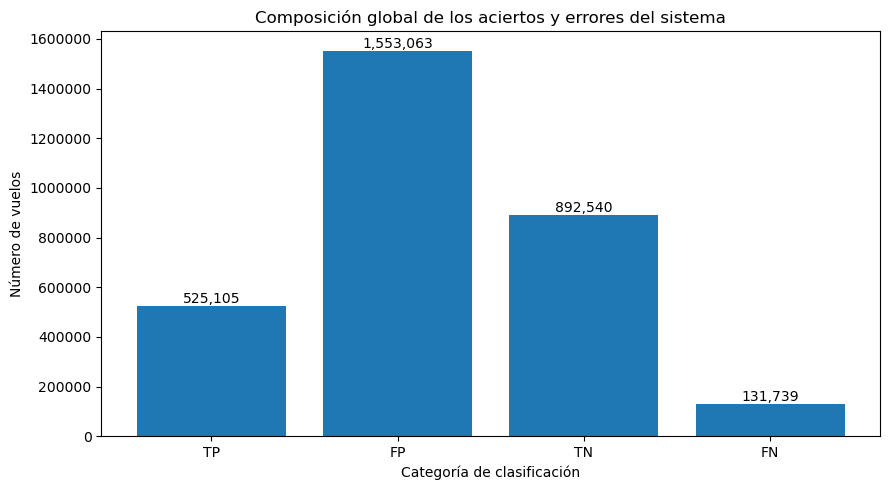

,category,description,flights
0,TP,Retraso detectado,525105
1,FP,Falsa alerta,1553063
2,TN,Sin retraso y sin alerta,892540
3,FN,Retraso no detectado,131739


In [6]:
# ---------------------------------------------------------
# 1. Recuperación de los componentes de la matriz de confusión
# ---------------------------------------------------------

total_flights = int(
    global_indicator_values["Vuelos analizados"]
)

total_observed_delays = int(
    round(
        total_flights
        * global_indicator_values["Tasa observada de retraso"]
    )
)

total_alerts = int(
    round(
        total_flights
        * global_indicator_values["Tasa de alerta"]
    )
)

recall = global_indicator_values["Cobertura de retrasos"]

true_positives = int(
    round(total_observed_delays * recall)
)

false_negatives = (
    total_observed_delays - true_positives
)

false_positives = (
    total_alerts - true_positives
)

true_negatives = (
    total_flights
    - true_positives
    - false_positives
    - false_negatives
)


# ---------------------------------------------------------
# 2. Preparación de los datos para la visualización
# ---------------------------------------------------------

confusion_composition_plot = pd.DataFrame(
    {
        "category": [
            "TP",
            "FP",
            "TN",
            "FN",
        ],
        "description": [
            "Retraso detectado",
            "Falsa alerta",
            "Sin retraso y sin alerta",
            "Retraso no detectado",
        ],
        "flights": [
            true_positives,
            false_positives,
            true_negatives,
            false_negatives,
        ],
    }
)


# ---------------------------------------------------------
# 3. Construcción de la visualización
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    confusion_composition_plot["category"],
    confusion_composition_plot["flights"],
)

ax.set_title(
    "Composición global de los aciertos y errores del sistema"
)
ax.set_ylabel("Número de vuelos")
ax.set_xlabel("Categoría de clasificación")
ax.ticklabel_format(
    style="plain",
    axis="y",
)

for bar, value in zip(
    bars,
    confusion_composition_plot["flights"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 4. Presentación de los valores representados
# ---------------------------------------------------------

confusion_composition_plot

#### Interpretación

La matriz de confusión muestra que el sistema detecta 525,105 retrasos, mientras que 131,739 retrasos no son anticipados.

El volumen de falsas alertas alcanza 1,553,063 vuelos, muy por encima de los verdaderos positivos, lo que confirma que la principal limitación operativa del sistema es su baja selectividad.

En conjunto, la composición refuerza la interpretación del modelo como herramienta de alerta temprana orientada a cobertura, pero con un coste elevado en falsas alertas.

## 4. Visualización temporal del comportamiento del sistema

Una vez caracterizado el funcionamiento global, el análisis visual se extenderá a la dimensión temporal para representar cómo varían los principales indicadores entre enero y mayo de 2026. Esta perspectiva permite determinar si los resultados agregados describen de forma uniforme todo el período externo o si existen diferencias relevantes entre meses.

La representación temporal considerará conjuntamente la evolución de los retrasos observados y de las alertas emitidas, seguida de las métricas asociadas a cobertura y selectividad. Esta separación permitirá distinguir los cambios en la frecuencia del fenómeno de las variaciones en el comportamiento operativo del sistema.

También se analizará la evolución del score de riesgo generado por el modelo. Dado que el threshold permanece fijo durante todo el período externo, los desplazamientos mensuales de la distribución del score proporcionan contexto para interpretar las diferencias observadas en la tasa de alerta.

Las variaciones identificadas tendrán una interpretación exclusivamente descriptiva. La evidencia disponible permite caracterizar diferencias temporales, pero no atribuirlas directamente a estacionalidad, drift o deterioro del modelo.

En este bloque se abordarán progresivamente:

1. Evolución mensual de retrasos y alertas.
2. Evolución mensual de cobertura, precisión y falsas alertas.
3. Evolución temporal del score de riesgo.

Como resultado se dispondrá de una representación visual de la variabilidad temporal del sistema durante los cinco meses que componen el período externo de evaluación.

### 4.1 Evolución mensual de retrasos y alertas

La primera perspectiva temporal comparará la evolución mensual de la tasa de retrasos observados y la tasa de alertas emitidas. El uso de tasas permite realizar comparaciones entre meses sin que las diferencias en el volumen total de vuelos condicionen directamente la representación.

Ambos indicadores se mostrarán sobre una misma escala temporal para analizar si sus variaciones siguen un comportamiento similar. La comparación permitirá observar hasta qué punto los cambios en la intensidad de las alertas coinciden con las variaciones mensuales de los retrasos reales.

La representación tendrá un carácter descriptivo y servirá como contexto para analizar posteriormente la evolución de las métricas de cobertura y selectividad.

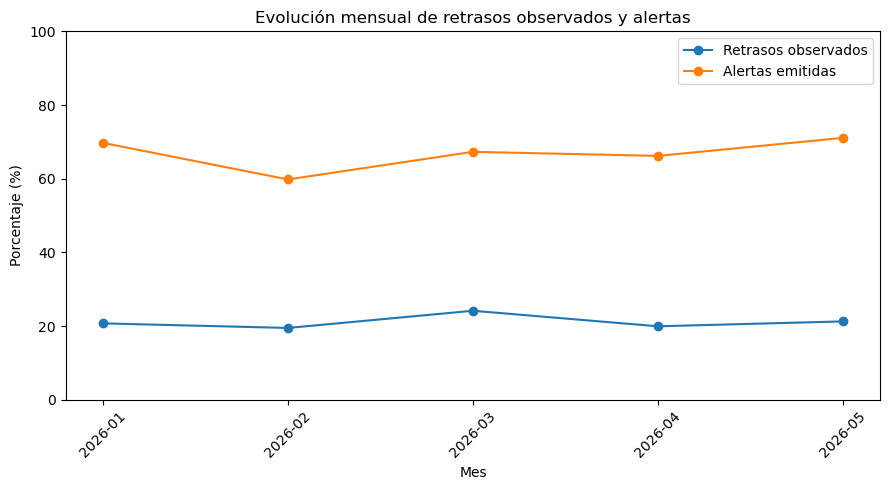

,analysis_month,delay_percentage,alert_percentage
0,2026-01,20.72515,69.717202
1,2026-02,19.483779,59.798267
2,2026-03,24.147669,67.290528
3,2026-04,19.92898,66.187331
4,2026-05,21.260422,71.081252


In [7]:
# ---------------------------------------------------------
# 1. Preparación de los indicadores temporales
# ---------------------------------------------------------

monthly_rates_plot = (
    temporal_visualization[
        [
            "analysis_month",
            "observed_delay_rate",
            "alert_rate",
        ]
    ]
    .copy()
    .sort_values("analysis_month")
)

monthly_rates_plot["delay_percentage"] = (
    monthly_rates_plot["observed_delay_rate"] * 100
)

monthly_rates_plot["alert_percentage"] = (
    monthly_rates_plot["alert_rate"] * 100
)


# ---------------------------------------------------------
# 2. Construcción de la visualización
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    monthly_rates_plot["analysis_month"],
    monthly_rates_plot["delay_percentage"],
    marker="o",
    label="Retrasos observados",
)

ax.plot(
    monthly_rates_plot["analysis_month"],
    monthly_rates_plot["alert_percentage"],
    marker="o",
    label="Alertas emitidas",
)

ax.set_title(
    "Evolución mensual de retrasos observados y alertas"
)
ax.set_xlabel("Mes")
ax.set_ylabel("Porcentaje (%)")
ax.set_ylim(0, 100)
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 3. Presentación de los valores representados
# ---------------------------------------------------------

monthly_rates_plot[
    [
        "analysis_month",
        "delay_percentage",
        "alert_percentage",
    ]
]

#### Interpretación

La tasa de retrasos varía entre 19.48 % y 24.15 %, mientras que la tasa de alertas oscila entre 59.80 % y 71.08 %.

Ambas series presentan variaciones mensuales que no siguen un patrón completamente paralelo. Marzo registra la mayor proporción de retrasos, mientras que mayo presenta la mayor tasa de alertas.

Estos resultados muestran variabilidad temporal en la intensidad de las alertas y justifican analizar posteriormente si también existen diferencias mensuales en la cobertura y selectividad del sistema.

### 4.2 Evolución mensual de cobertura, precisión y falsas alertas

La evolución de las tasas de retraso y alerta no permite determinar por sí sola si la capacidad operativa del sistema permanece estable entre meses. Para ello es necesario analizar conjuntamente las métricas asociadas a cobertura y selectividad.

Se representarán Recall, Precision y la proporción de falsas alertas entre enero y mayo de 2026. Recall permitirá observar la proporción mensual de retrasos detectados, mientras que Precision y las falsas alertas mostrarán el nivel de acierto de las alertas emitidas.

La comparación permitirá determinar si el resultado global del sistema representa de forma homogénea todo el período externo o si existen diferencias mensuales relevantes en su comportamiento operativo.

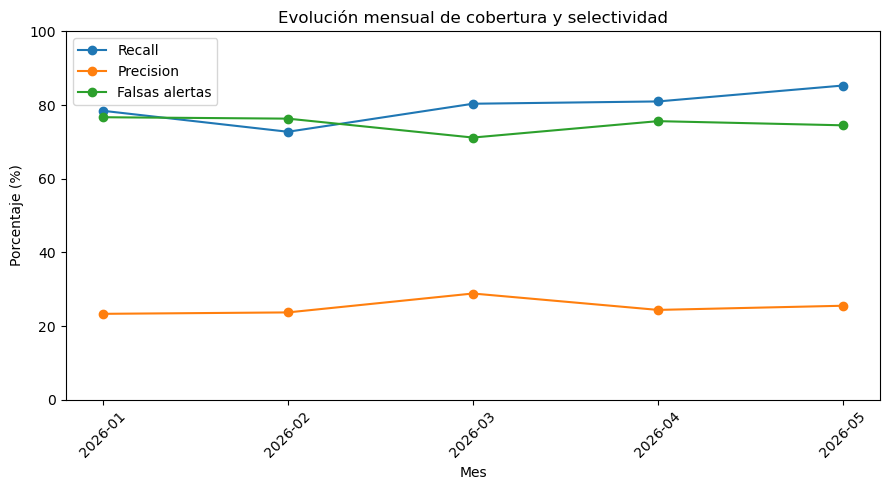

,analysis_month,recall_percentage,precision_percentage,false_alert_percentage
0,2026-01,78.432149,23.315882,76.684118
1,2026-02,72.738384,23.699994,76.300006
2,2026-03,80.346865,28.833026,71.166974
3,2026-04,80.969717,24.379950,75.620050
4,2026-05,85.289878,25.510226,74.489774


In [8]:
# ---------------------------------------------------------
# 1. Preparación de los indicadores mensuales
# ---------------------------------------------------------

monthly_performance_plot = (
    temporal_visualization[
        [
            "analysis_month",
            "recall",
            "precision",
            "false_alert_share",
        ]
    ]
    .copy()
    .sort_values("analysis_month")
)

monthly_performance_plot["recall_percentage"] = (
    monthly_performance_plot["recall"] * 100
)

monthly_performance_plot["precision_percentage"] = (
    monthly_performance_plot["precision"] * 100
)

monthly_performance_plot["false_alert_percentage"] = (
    monthly_performance_plot["false_alert_share"] * 100
)


# ---------------------------------------------------------
# 2. Construcción de la visualización
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    monthly_performance_plot["analysis_month"],
    monthly_performance_plot["recall_percentage"],
    marker="o",
    label="Recall",
)

ax.plot(
    monthly_performance_plot["analysis_month"],
    monthly_performance_plot["precision_percentage"],
    marker="o",
    label="Precision",
)

ax.plot(
    monthly_performance_plot["analysis_month"],
    monthly_performance_plot["false_alert_percentage"],
    marker="o",
    label="Falsas alertas",
)

ax.set_title(
    "Evolución mensual de cobertura y selectividad"
)
ax.set_xlabel("Mes")
ax.set_ylabel("Porcentaje (%)")
ax.set_ylim(0, 100)
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 3. Presentación de los valores representados
# ---------------------------------------------------------

monthly_performance_plot[
    [
        "analysis_month",
        "recall_percentage",
        "precision_percentage",
        "false_alert_percentage",
    ]
]

#### Interpretación

El Recall presenta una variación mensual relevante, desde 72.74 % en febrero hasta 85.29 % en mayo, por lo que el 79.94 % global no representa un comportamiento uniforme durante todo el período.

La Precision permanece entre 23.32 % y 28.83 %, mientras que las falsas alertas superan el 71 % en todos los meses. Marzo presenta la mayor Precision y la menor proporción de falsas alertas.

En conjunto, el sistema mantiene una selectividad limitada durante todo el período, aunque su capacidad de detección presenta diferencias temporales apreciables.

### 4.3 Evolución temporal del score de riesgo

La caracterización temporal se completa mediante el análisis de la evolución del score de riesgo generado por el modelo. Este valor se interpreta como una medida de ordenación del riesgo y no como una probabilidad calibrada de retraso.

Se representarán la media y la mediana mensual del score junto con el threshold de decisión utilizado durante todo el período externo. Al mantenerse fijo este criterio, los desplazamientos de la distribución del score proporcionan contexto para interpretar las diferencias observadas en la tasa de alerta.

El análisis tendrá un carácter descriptivo y permitirá identificar cambios en la localización de los scores entre meses sin atribuirlos directamente a drift o deterioro del modelo.

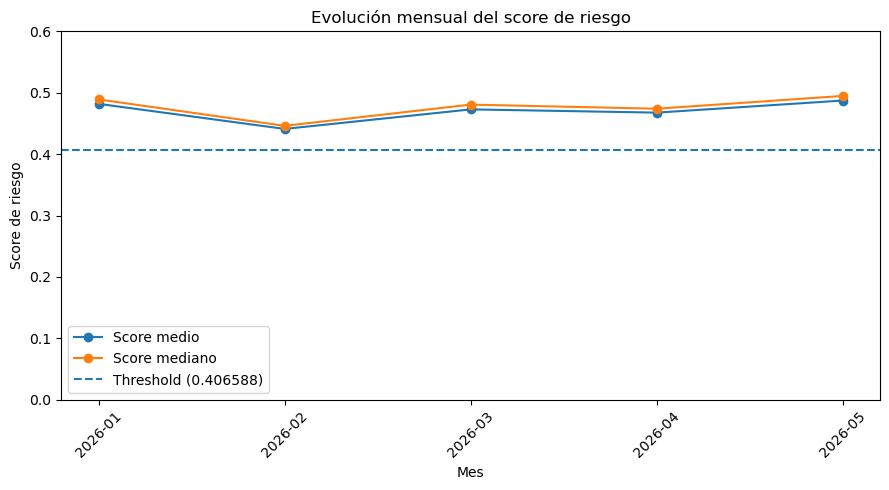

,analysis_month,mean_score,median_score,std_score
0,2026-01,0.481893,0.489112,0.129472
1,2026-02,0.441056,0.446066,0.127645
2,2026-03,0.472874,0.480681,0.129456
3,2026-04,0.467614,0.473932,0.127722
4,2026-05,0.487276,0.494814,0.126843


In [9]:
# ---------------------------------------------------------
# 1. Preparación de los indicadores mensuales del score
# ---------------------------------------------------------

monthly_score_plot = (
    temporal_visualization[
        [
            "analysis_month",
            "mean_score",
            "median_score",
            "std_score",
        ]
    ]
    .copy()
    .sort_values("analysis_month")
)

decision_threshold = 0.406588


# ---------------------------------------------------------
# 2. Construcción de la visualización
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    monthly_score_plot["analysis_month"],
    monthly_score_plot["mean_score"],
    marker="o",
    label="Score medio",
)

ax.plot(
    monthly_score_plot["analysis_month"],
    monthly_score_plot["median_score"],
    marker="o",
    label="Score mediano",
)

ax.axhline(
    y=decision_threshold,
    linestyle="--",
    label=f"Threshold ({decision_threshold:.6f})",
)

ax.set_title(
    "Evolución mensual del score de riesgo"
)
ax.set_xlabel("Mes")
ax.set_ylabel("Score de riesgo")
ax.set_ylim(0, 0.60)
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 3. Presentación de los valores representados
# ---------------------------------------------------------

monthly_score_plot

#### Interpretación

El score presenta variaciones moderadas entre meses, con su menor nivel medio en febrero (0.4411) y el mayor en mayo (0.4873). La dispersión permanece estable, con desviaciones estándar próximas a 0.13 durante todo el período.

La media y la mediana permanecen por encima del threshold fijo de 0.406588, aunque esto no implica que todos los vuelos superen dicho criterio. Los desplazamientos mensuales del score son coherentes con las diferencias observadas en la tasa de alerta.

Estas variaciones se interpretan de forma descriptiva y no constituyen por sí solas evidencia de drift o deterioro del modelo.

## 5. Visualización operacional

Una vez analizado el comportamiento temporal, la visualización se orientará a las principales dimensiones operacionales del sistema. El objetivo es representar cómo varían la intensidad de las alertas, la cobertura y la selectividad entre diferentes contextos de operación.

El análisis comenzará con las franjas horarias programadas de salida, manteniendo su orden cronológico para identificar cambios a lo largo del día. Posteriormente se comparará el comportamiento entre aerolíneas, considerando conjuntamente las métricas operativas y el volumen de vuelos de cada categoría.

Finalmente, se representará la concentración de falsas alertas y retrasos no detectados. Esta perspectiva permitirá diferenciar los segmentos donde se acumulan ambos tipos de error, teniendo en cuenta que su concentración puede estar condicionada por el volumen de operaciones.

Las comparaciones tendrán un carácter descriptivo y no implicarán relaciones causales entre las características operacionales y el comportamiento del sistema.

En este bloque se abordarán progresivamente:

1. Comportamiento según las franjas horarias programadas.
2. Comparación entre aerolíneas.
3. Concentración operacional de falsas alertas y retrasos no detectados.

Como resultado se dispondrá de una representación visual de las principales diferencias operacionales del sistema y de la distribución de sus errores.

### 5.1 Comportamiento según las franjas horarias programadas

El comportamiento del sistema presenta diferencias relevantes según la hora programada de salida. Para representar esta variación se analizarán conjuntamente la tasa de alerta y Recall a lo largo de las franjas horarias, manteniendo su orden cronológico.

Esta comparación permitirá identificar en qué momentos del día el incremento de la cobertura está acompañado por una expansión de las alertas. La interpretación deberá considerar ambos indicadores conjuntamente, ya que un Recall elevado no implica necesariamente una mayor capacidad de discriminación si prácticamente todos los vuelos de una franja son clasificados como alerta.

La representación permitirá caracterizar visualmente la evolución intradiaria del sistema y localizar los períodos en los que predominan la pérdida de cobertura o la pérdida de selectividad.

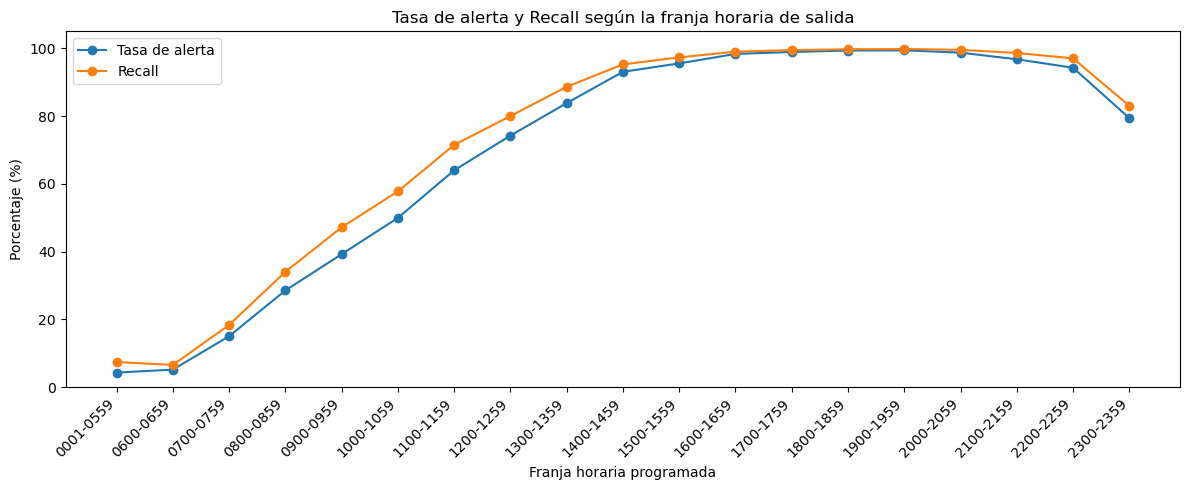

,DEP_TIME_BLK,flights,alert_percentage,recall_percentage
0,0001-0559,87493,4.297487,7.422987
1,0600-0659,209879,5.179175,6.563583
2,0700-0759,226450,15.031574,18.338129
3,0800-0859,211494,28.545491,34.047726
4,0900-0959,178254,39.224926,47.158362
5,1000-1059,198488,49.956672,57.774882
6,1100-1159,190075,63.99053,71.475033
7,1200-1259,195766,74.228416,80.004867
8,1300-1359,182109,83.821777,88.626267
9,1400-1459,184049,93.067607,95.250414


In [10]:
# ---------------------------------------------------------
# 1. Preparación de los indicadores por franja horaria
# ---------------------------------------------------------

time_block_performance_plot = (
    time_block_visualization[
        [
            "DEP_TIME_BLK",
            "time_block_order",
            "flights",
            "alert_rate",
            "recall",
        ]
    ]
    .copy()
    .sort_values("time_block_order")
)

time_block_performance_plot["alert_percentage"] = (
    time_block_performance_plot["alert_rate"] * 100
)

time_block_performance_plot["recall_percentage"] = (
    time_block_performance_plot["recall"] * 100
)


# ---------------------------------------------------------
# 2. Construcción de la visualización
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    time_block_performance_plot["DEP_TIME_BLK"],
    time_block_performance_plot["alert_percentage"],
    marker="o",
    label="Tasa de alerta",
)

ax.plot(
    time_block_performance_plot["DEP_TIME_BLK"],
    time_block_performance_plot["recall_percentage"],
    marker="o",
    label="Recall",
)

ax.set_title(
    "Tasa de alerta y Recall según la franja horaria de salida"
)
ax.set_xlabel("Franja horaria programada")
ax.set_ylabel("Porcentaje (%)")
ax.set_ylim(0, 105)
ax.legend()

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 3. Presentación de los valores representados
# ---------------------------------------------------------

time_block_performance_plot[
    [
        "DEP_TIME_BLK",
        "flights",
        "alert_percentage",
        "recall_percentage",
    ]
]

#### Interpretación

El comportamiento del sistema varía claramente a lo largo del día. Durante las primeras franjas horarias la tasa de alerta y Recall son reducidos, mientras que ambos indicadores aumentan progresivamente hasta alcanzar valores próximos al 100 % durante la tarde.

A partir de las 14:00 la tasa de alerta supera el 93 %, y entre las 16:00 y las 19:59 prácticamente todos los vuelos son clasificados como alerta. En estas franjas la elevada cobertura se obtiene mediante una pérdida importante de selectividad.

Por tanto, el sistema presenta una marcada dependencia de la franja horaria: mayor pérdida de cobertura durante la mañana y mayor pérdida de selectividad durante la tarde.

### 5.2 Comparación entre aerolíneas

La siguiente dimensión operacional corresponde a la aerolínea operadora. El objetivo es comparar la cobertura alcanzada por el sistema entre compañías y determinar en qué medida dicha cobertura está asociada a una mayor intensidad de alertas.

La comparación se realizará mediante Recall y tasa de alerta, manteniendo el volumen de vuelos como referencia para contextualizar las diferencias observadas. De esta forma, una métrica elevada en una aerolínea con menor representación no tendrá el mismo peso descriptivo que un comportamiento similar en una compañía con un volumen considerable de operaciones.

Las diferencias identificadas se interpretarán exclusivamente como variabilidad descriptiva del comportamiento del sistema entre aerolíneas, sin atribuirlas a características causales de las compañías.

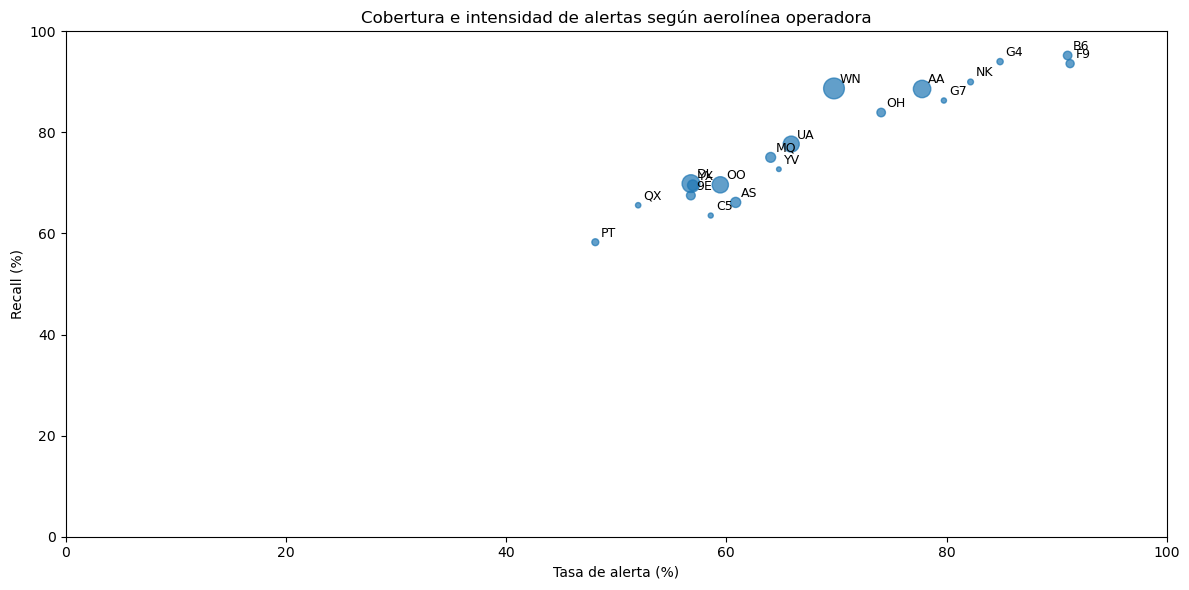

,OP_UNIQUE_CARRIER,flights,alert_percentage,recall_percentage,precision,alert_delay_lift
0,WN,557982,69.776624,88.700373,0.281984,1.271205
1,DL,408780,56.7836,69.868571,0.219632,1.230436
2,AA,393936,77.779639,88.595276,0.265018,1.139055
3,OO,342154,59.448085,69.629761,0.250197,1.17127
4,UA,332937,65.892046,77.687706,0.218421,1.179015
5,YX,144862,56.949373,69.550397,0.247327,1.221267
6,AS,132614,60.845009,66.147147,0.201452,1.087142
7,MQ,125950,64.025407,75.060272,0.216208,1.172351
8,9E,99998,56.773135,67.524569,0.269887,1.189375
9,B6,94444,91.001016,95.218702,0.282925,1.046348


In [11]:
# ---------------------------------------------------------
# 1. Preparación de los indicadores por aerolínea
# ---------------------------------------------------------

carrier_performance_plot = (
    carrier_visualization[
        [
            "OP_UNIQUE_CARRIER",
            "flights",
            "population_share",
            "alert_rate",
            "recall",
            "precision",
            "alert_delay_lift",
        ]
    ]
    .copy()
    .sort_values("flights", ascending=False)
)

carrier_performance_plot["alert_percentage"] = (
    carrier_performance_plot["alert_rate"] * 100
)

carrier_performance_plot["recall_percentage"] = (
    carrier_performance_plot["recall"] * 100
)


# ---------------------------------------------------------
# 2. Construcción de la visualización
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(
    carrier_performance_plot["alert_percentage"],
    carrier_performance_plot["recall_percentage"],
    s=carrier_performance_plot["flights"] / 2500,
    alpha=0.7,
)

for _, row in carrier_performance_plot.iterrows():
    ax.annotate(
        row["OP_UNIQUE_CARRIER"],
        (row["alert_percentage"], row["recall_percentage"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=9,
    )

ax.set_title("Cobertura e intensidad de alertas según aerolínea operadora")
ax.set_xlabel("Tasa de alerta (%)")
ax.set_ylabel("Recall (%)")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 3. Presentación de los indicadores de apoyo
# ---------------------------------------------------------

carrier_performance_plot[
    [
        "OP_UNIQUE_CARRIER",
        "flights",
        "alert_percentage",
        "recall_percentage",
        "precision",
        "alert_delay_lift",
    ]
]

#### Interpretación

El comportamiento del sistema presenta diferencias entre aerolíneas. El Recall varía entre 58.27 % y 95.22 %, mientras que la tasa de alerta oscila entre 48.09 % y 91.23 %.

Las mayores coberturas no implican necesariamente una mejor discriminación. B6 y F9 superan el 93 % de Recall, pero clasifican como alerta más del 91 % de sus vuelos y presentan un lift próximo a 1. En contraste, WN alcanza un Recall del 88.70 % con una tasa de alerta del 69.78 % y un lift de 1.27, mostrando una mayor concentración relativa de retrasos dentro del grupo alertado.

Estas diferencias describen una variabilidad operacional relevante entre compañías, aunque no permiten atribuir causalidad a la aerolínea ni comparar directamente su calidad operativa.

### 5.3 Concentración operacional de falsas alertas y retrasos no detectados

La evaluación operacional se completa analizando la distribución de los principales errores de clasificación. Las falsas alertas representan vuelos clasificados como riesgo que finalmente no presentan retraso, mientras que los falsos negativos corresponden a retrasos que el sistema no consigue identificar.

La concentración de ambos errores se analizará según la franja horaria programada de salida. Esta perspectiva permite relacionar los errores con el comportamiento intradiario observado previamente y determinar en qué períodos se concentra cada tipo de fallo.

Para facilitar la comparación se utilizará la participación de cada franja sobre el total de falsas alertas y falsos negativos, manteniendo además sus frecuencias absolutas como referencia del volumen involucrado.

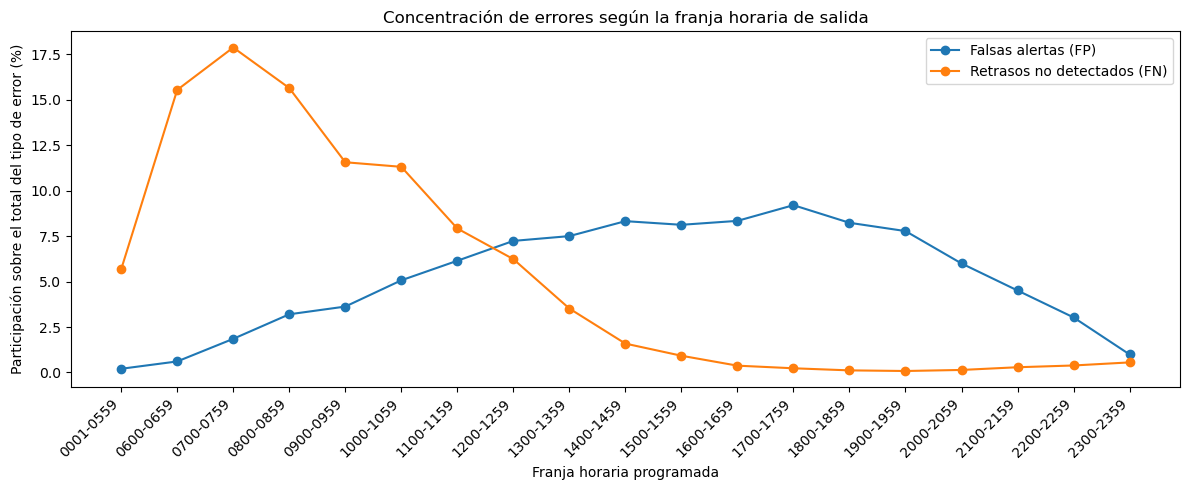

,category,FP,FN,fp_percentage,fn_percentage
0,0001-0559,3160,7483,0.203469,5.680171
1,0600-0659,9431,20485,0.607252,15.549685
2,0700-0759,28749,23557,1.851116,17.881569
3,0800-0859,49728,20618,3.201931,15.650643
4,0900-0959,56320,15239,3.626382,11.567569
5,1000-1059,78760,14908,5.071269,11.316315
6,1100-1159,95478,10437,6.147722,7.922483
7,1200-1259,112440,8216,7.239887,6.236574
8,1300-1359,116538,4634,7.503752,3.517561
9,1400-1459,129316,2093,8.326513,1.588747


In [12]:
# ---------------------------------------------------------
# 1. Recuperación de los errores por franja horaria
# ---------------------------------------------------------

time_error_concentration = (
    error_concentration_visualization[
        error_concentration_visualization["dimension"] == "Franja horaria"
    ]
    .copy()
    .sort_values("category_order")
)

time_error_concentration["fp_percentage"] = (
    time_error_concentration["fp_share"] * 100
)

time_error_concentration["fn_percentage"] = (
    time_error_concentration["fn_share"] * 100
)


# ---------------------------------------------------------
# 2. Representación de la concentración de errores
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    time_error_concentration["category"],
    time_error_concentration["fp_percentage"],
    marker="o",
    label="Falsas alertas (FP)",
)

ax.plot(
    time_error_concentration["category"],
    time_error_concentration["fn_percentage"],
    marker="o",
    label="Retrasos no detectados (FN)",
)

ax.set_title("Concentración de errores según la franja horaria de salida")
ax.set_xlabel("Franja horaria programada")
ax.set_ylabel("Participación sobre el total del tipo de error (%)")
ax.legend()

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 3. Presentación de los valores representados
# ---------------------------------------------------------

time_error_concentration[
    [
        "category",
        "FP",
        "FN",
        "fp_percentage",
        "fn_percentage",
    ]
]

#### Interpretación

Los errores presentan una distribución intradiaria claramente diferenciada. Los retrasos no detectados se concentran principalmente durante la mañana: entre las 06:00 y las 10:59 se acumula aproximadamente el 71.97 % de todos los falsos negativos, con el máximo individual entre las 07:00 y las 07:59 (17.88 %).

En sentido contrario, las falsas alertas aumentan su participación conforme avanza el día y alcanzan su mayor concentración entre las 17:00 y las 17:59 (9.21 %). Este patrón es coherente con la elevada tasa de alerta observada durante la tarde.

En consecuencia, el sistema presenta dos limitaciones operacionales diferenciadas: pérdida de cobertura principalmente durante la mañana y pérdida de selectividad durante la tarde.

## 6. Visualización geográfica

El análisis se extiende ahora a la dimensión geográfica con el objetivo de representar cómo varía el comportamiento del sistema entre los aeropuertos incluidos en el período externo de 2026. Esta perspectiva permite determinar si los niveles de cobertura, intensidad de alerta y selectividad presentan diferencias relevantes según el aeropuerto asociado a la operación.

El análisis distinguirá entre aeropuerto de origen y aeropuerto de destino, evitando combinar ambas funciones operativas en una única categoría. Dado que el producto persistido contiene 365 aeropuertos para cada perspectiva, las visualizaciones priorizarán aquellos con suficiente volumen de operaciones para evitar comparaciones dominadas por muestras reducidas.

Las diferencias observadas tendrán un carácter descriptivo. No se interpretarán como evidencia de que un aeropuerto cause un determinado comportamiento del modelo, sino como una caracterización espacial de su funcionamiento durante el período evaluado.

En este bloque se abordarán progresivamente:

1. Distribución de los indicadores por aeropuerto de origen.
2. Distribución de los indicadores por aeropuerto de destino.
3. Comparación de cobertura y selectividad entre aeropuertos.

Como resultado se obtendrá una síntesis geográfica del comportamiento del sistema que permitirá identificar patrones relevantes para su posterior incorporación al dashboard en Power BI.

### 6.1 Distribución de los indicadores por aeropuerto de origen

El análisis geográfico comienza con los aeropuertos de origen. Debido al elevado número de aeropuertos disponibles, una representación simultánea de todas las categorías dificultaría la interpretación y otorgaría excesiva relevancia visual a aeropuertos con volúmenes reducidos.

Por este motivo, la visualización se concentrará en los 20 aeropuertos de origen con mayor número de vuelos durante el período analizado. Para cada uno se compararán la tasa de alerta y Recall, manteniendo el volumen de operaciones, Precision y lift como indicadores complementarios.

Este criterio permite analizar la variabilidad geográfica sobre una parte operacionalmente relevante del conjunto de datos sin interpretar las diferencias observadas como efectos causales asociados al aeropuerto.

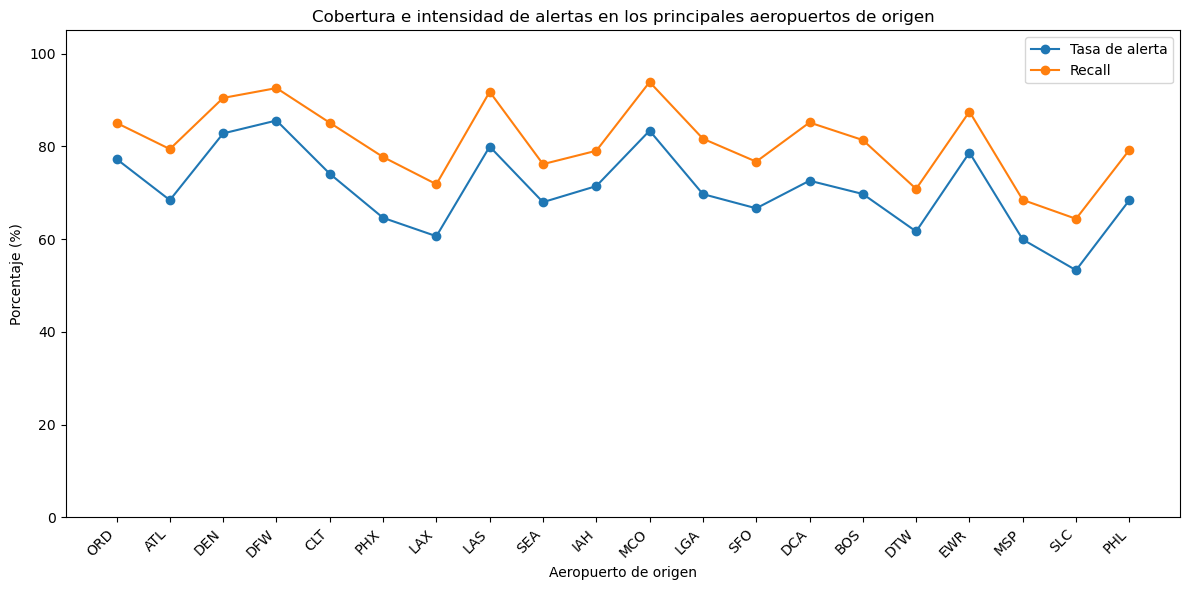

,airport,flights,alert_percentage,recall_percentage,precision,alert_delay_lift
497,ORD,155123,77.261915,85.042075,0.326322,1.100699
45,ATL,139855,68.396554,79.404565,0.250941,1.160944
187,DEN,125889,82.781657,90.429827,0.219243,1.09239
189,DFW,120536,85.56199,92.551027,0.273472,1.081684
147,CLT,92686,74.082386,85.075024,0.232859,1.148384
525,PHX,86074,64.582801,77.689266,0.243861,1.20294
383,LAX,76674,60.615072,71.825869,0.233949,1.184951
379,LAS,70672,79.943966,91.753909,0.238893,1.147728
621,SEA,69643,67.958014,76.157228,0.186676,1.120651
333,IAH,68865,71.422348,79.039373,0.196727,1.106648


In [13]:
# ---------------------------------------------------------
# 1. Selección de aeropuertos de origen
# ---------------------------------------------------------

origin_airport_plot = (
    airport_visualization[
        airport_visualization["airport_role"] == "Origen"
    ]
    .copy()
    .sort_values("flights", ascending=False)
    .head(20)
)

origin_airport_plot["alert_percentage"] = (
    origin_airport_plot["alert_rate"] * 100
)

origin_airport_plot["recall_percentage"] = (
    origin_airport_plot["recall"] * 100
)


# ---------------------------------------------------------
# 2. Ordenación para la representación
# ---------------------------------------------------------

origin_airport_plot = origin_airport_plot.sort_values(
    "flights",
    ascending=False,
)


# ---------------------------------------------------------
# 3. Construcción de la visualización
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

x_positions = np.arange(len(origin_airport_plot))

ax.plot(
    x_positions,
    origin_airport_plot["alert_percentage"],
    marker="o",
    label="Tasa de alerta",
)

ax.plot(
    x_positions,
    origin_airport_plot["recall_percentage"],
    marker="o",
    label="Recall",
)

ax.set_title(
    "Cobertura e intensidad de alertas en los principales aeropuertos de origen"
)
ax.set_xlabel("Aeropuerto de origen")
ax.set_ylabel("Porcentaje (%)")
ax.set_ylim(0, 105)
ax.set_xticks(x_positions)
ax.set_xticklabels(
    origin_airport_plot["airport"],
    rotation=45,
    ha="right",
)
ax.legend()

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 4. Presentación de los indicadores de apoyo
# ---------------------------------------------------------

origin_airport_plot[
    [
        "airport",
        "flights",
        "alert_percentage",
        "recall_percentage",
        "precision",
        "alert_delay_lift",
    ]
]

#### Interpretación

Entre los principales aeropuertos de origen se observan diferencias relevantes en el comportamiento del sistema. La tasa de alerta varía desde 53.29 % en SLC hasta 85.56 % en DFW, mientras que el Recall oscila entre 64.37 % y 93.85 %.

Los aeropuertos con mayor cobertura suelen presentar también una mayor intensidad de alertas. MCO alcanza el Recall más elevado, 93.85 %, con una tasa de alerta del 83.37 %, mientras que SLC presenta simultáneamente los valores más bajos de ambos indicadores.

La variabilidad observada confirma que el comportamiento del sistema no es homogéneo entre aeropuertos de origen. No obstante, estas diferencias deben interpretarse como patrones descriptivos y no como efectos causales asociados a los aeropuertos.

### 6.2 Distribución de los indicadores por aeropuerto de destino

El análisis geográfico continúa considerando el aeropuerto de destino. Para mantener la comparabilidad con la perspectiva de origen, se seleccionarán nuevamente los 20 aeropuertos con mayor volumen de vuelos durante el período analizado.

La representación comparará la tasa de alerta y Recall, utilizando el volumen de operaciones, Precision y lift como indicadores complementarios. El objetivo es determinar si el comportamiento del sistema también presenta variabilidad entre los principales destinos y caracterizar la relación entre cobertura e intensidad de alertas.

La utilización del mismo criterio de selección y de las mismas métricas permite posteriormente contrastar de forma coherente las perspectivas de origen y destino.

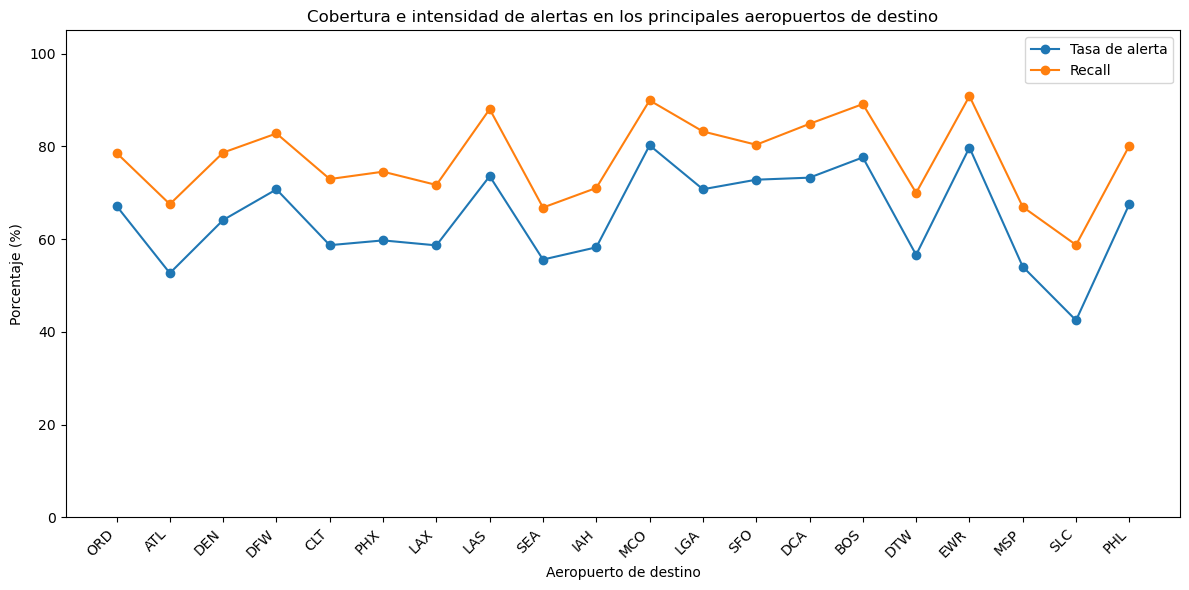

,airport,flights,alert_percentage,recall_percentage,precision,alert_delay_lift
496,ORD,154482,67.148276,78.577050,0.308015,1.170202
44,ATL,139815,52.65744,67.528654,0.224875,1.282414
186,DEN,125866,64.111039,78.648779,0.222309,1.226759
188,DFW,120114,70.717818,82.769067,0.238021,1.170413
146,CLT,92740,58.687729,72.938759,0.202197,1.242828
524,PHX,86126,59.714836,74.527040,0.227494,1.248049
382,LAX,76744,58.643021,71.666434,0.228575,1.22208
378,LAS,70720,73.563348,88.015214,0.244637,1.196455
620,SEA,69633,55.584278,66.796068,0.208939,1.201708
332,IAH,68841,58.222571,71.019274,0.204087,1.219789


In [14]:
# ---------------------------------------------------------
# 1. Selección de aeropuertos de destino
# ---------------------------------------------------------

destination_airport_plot = (
    airport_visualization[
        airport_visualization["airport_role"] == "Destino"
    ]
    .copy()
    .sort_values("flights", ascending=False)
    .head(20)
)

destination_airport_plot["alert_percentage"] = (
    destination_airport_plot["alert_rate"] * 100
)

destination_airport_plot["recall_percentage"] = (
    destination_airport_plot["recall"] * 100
)


# ---------------------------------------------------------
# 2. Ordenación para la representación
# ---------------------------------------------------------

destination_airport_plot = destination_airport_plot.sort_values(
    "flights",
    ascending=False,
)


# ---------------------------------------------------------
# 3. Construcción de la visualización
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

x_positions = np.arange(len(destination_airport_plot))

ax.plot(
    x_positions,
    destination_airport_plot["alert_percentage"],
    marker="o",
    label="Tasa de alerta",
)

ax.plot(
    x_positions,
    destination_airport_plot["recall_percentage"],
    marker="o",
    label="Recall",
)

ax.set_title(
    "Cobertura e intensidad de alertas en los principales aeropuertos de destino"
)
ax.set_xlabel("Aeropuerto de destino")
ax.set_ylabel("Porcentaje (%)")
ax.set_ylim(0, 105)
ax.set_xticks(x_positions)
ax.set_xticklabels(
    destination_airport_plot["airport"],
    rotation=45,
    ha="right",
)
ax.legend()

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 4. Presentación de los indicadores de apoyo
# ---------------------------------------------------------

destination_airport_plot[
    [
        "airport",
        "flights",
        "alert_percentage",
        "recall_percentage",
        "precision",
        "alert_delay_lift",
    ]
]

#### Interpretación

Entre los principales aeropuertos de destino también se observa una variabilidad relevante. La tasa de alerta oscila entre 42.49 % en SLC y 80.21 % en MCO, mientras que el Recall varía entre 58.74 % y 90.82 %.

EWR alcanza el mayor Recall, 90.82 %, con una tasa de alerta del 79.74 %, mientras que SLC presenta los valores más bajos de ambos indicadores. Destaca además que SLC registra el mayor lift, 1.38, lo que evidencia que una menor cobertura puede coexistir con una mayor concentración relativa de retrasos entre las alertas emitidas.

Por tanto, la perspectiva de destino confirma que cobertura y selectividad deben analizarse conjuntamente y que el comportamiento del sistema no es homogéneo entre aeropuertos.

### 6.3 Comparación de cobertura y selectividad entre aeropuertos

La última perspectiva geográfica integra los aeropuertos de origen y destino para analizar conjuntamente la relación entre cobertura e intensidad de alertas.

Para reducir la influencia de categorías con escaso volumen, la comparación se limitará a aeropuertos con al menos 10,000 vuelos en el período analizado. Cada observación representará una combinación entre aeropuerto y función operacional, diferenciando entre origen y destino.

La posición respecto a la tasa de alerta y Recall permitirá identificar diferentes equilibrios entre cobertura y selectividad. Una cobertura elevada acompañada por una tasa de alerta igualmente elevada deberá interpretarse con cautela, ya que puede reflejar una menor capacidad para discriminar entre vuelos con distinto nivel de riesgo.

Esta comparación sintetiza la heterogeneidad geográfica del sistema sin establecer relaciones causales entre el aeropuerto y el comportamiento predictivo.

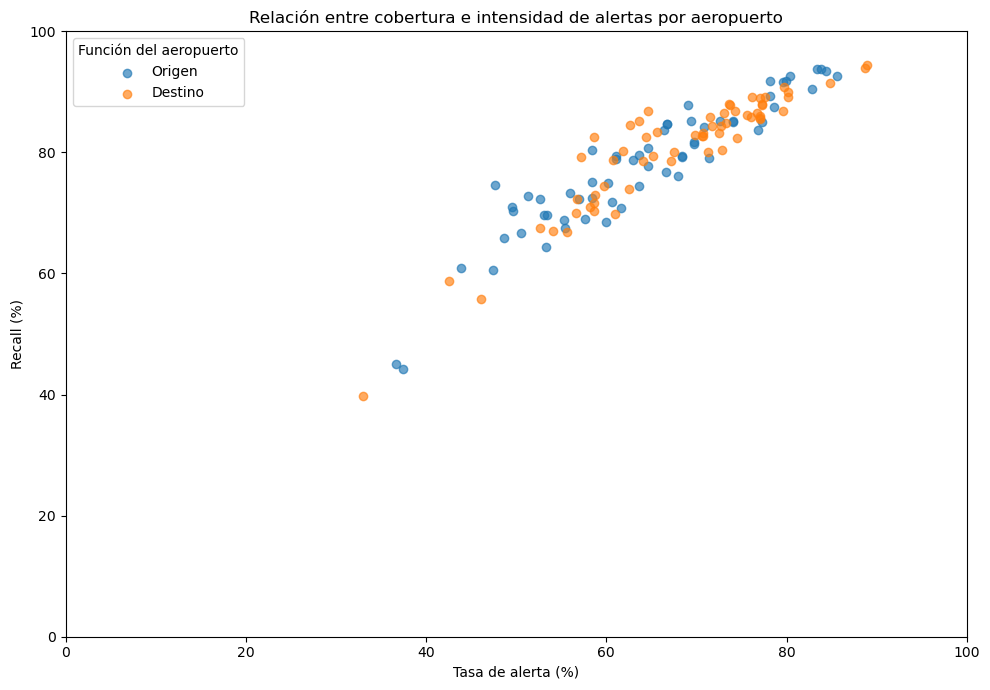

,airport_role,airports,flights,mean_alert_rate,mean_recall,mean_precision,mean_lift
0,Destino,62,2509906,0.680974,0.807082,0.252843,1.194049
1,Origen,62,2510337,0.641327,0.777248,0.249802,1.225144


In [15]:
# ---------------------------------------------------------
# 1. Preparación de los aeropuertos con volumen suficiente
# ---------------------------------------------------------

airport_comparison_plot = (
    airport_visualization[
        airport_visualization["flights"] >= 10000
    ]
    .copy()
)

airport_comparison_plot["alert_percentage"] = (
    airport_comparison_plot["alert_rate"] * 100
)

airport_comparison_plot["recall_percentage"] = (
    airport_comparison_plot["recall"] * 100
)


# ---------------------------------------------------------
# 2. Construcción de la comparación origen-destino
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 7))

for airport_role in ["Origen", "Destino"]:

    role_data = airport_comparison_plot[
        airport_comparison_plot["airport_role"] == airport_role
    ]

    ax.scatter(
        role_data["alert_percentage"],
        role_data["recall_percentage"],
        alpha=0.65,
        label=airport_role,
    )

ax.set_title(
    "Relación entre cobertura e intensidad de alertas por aeropuerto"
)
ax.set_xlabel("Tasa de alerta (%)")
ax.set_ylabel("Recall (%)")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.legend(title="Función del aeropuerto")

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 3. Resumen descriptivo por función operacional
# ---------------------------------------------------------

airport_role_summary = (
    airport_comparison_plot
    .groupby("airport_role")
    .agg(
        airports=("airport", "nunique"),
        flights=("flights", "sum"),
        mean_alert_rate=("alert_rate", "mean"),
        mean_recall=("recall", "mean"),
        mean_precision=("precision", "mean"),
        mean_lift=("alert_delay_lift", "mean"),
    )
    .reset_index()
)

airport_role_summary

#### Interpretación

La comparación conjunta muestra una relación positiva clara entre la tasa de alerta y Recall: los aeropuertos con mayor cobertura tienden también a clasificar una mayor proporción de vuelos como alerta.

Entre los 62 aeropuertos analizados en cada función, los destinos presentan en promedio una tasa de alerta del 68.10 % y un Recall del 80.71 %, frente al 64.13 % y 77.72 % registrados en origen. La Precision media es similar en ambas perspectivas, alrededor del 25 %.

Estos resultados confirman que las diferencias geográficas de cobertura están estrechamente relacionadas con la intensidad de alertas. Por ello, un Recall elevado por aeropuerto no debe interpretarse aisladamente como evidencia de una mayor capacidad discriminativa.

## 7. Preparación de la capa analítica para Power BI

La fase final de preparación de datos tiene como objetivo organizar los productos necesarios para construir el dashboard del TFM en Power BI. A diferencia de las visualizaciones anteriores, centradas principalmente en el comportamiento del sistema de alerta temprana, el dashboard integrará también una perspectiva descriptiva del conjunto completo de vuelos analizados.

Esta ampliación permitirá explorar los 32,761,129 registros mediante variables temporales, geográficas y operacionales, incluyendo información sobre horarios, retrasos, cancelaciones, desvíos y causas de retraso. Algunas de estas variables fueron excluidas correctamente del modelo predictivo por no estar disponibles en el momento de realizar la predicción, pero conservan valor para el análisis retrospectivo de la operación aérea.

Los datos procesados se encuentran distribuidos en 354 archivos Parquet particionados temporalmente y con un esquema homogéneo de 45 variables. Para facilitar su posterior incorporación a Power BI, estos productos se consolidarán físicamente en una única tabla de hechos, conservando el esquema y los registros originales sin introducir nuevas transformaciones sobre los datos.

La consolidación se realizará de forma incremental para evitar cargar simultáneamente los más de 32 millones de registros en memoria. El archivo resultante constituirá la fuente principal del análisis descriptivo general en Power BI.

Las tablas de referencia utilizadas para interpretar códigos de aeropuertos y aerolíneas se mantendrán separadas de la tabla principal. Las relaciones entre estas fuentes se establecerán posteriormente dentro del modelo semántico de Power BI, evitando incorporar información descriptiva redundante en la tabla de hechos.

Asimismo, se preparará una fuente específica para las predicciones correspondientes al período externo de enero a mayo de 2026. Esta información permitirá disponer de una página dedicada al comportamiento del sistema predictivo, manteniendo claramente diferenciados el análisis descriptivo retrospectivo y los resultados del sistema de alerta temprana.

Los productos agregados construidos durante el análisis operativo también serán incorporados a la capa analítica cuando permitan representar de forma más eficiente los indicadores previamente obtenidos. Su utilización tendrá exclusivamente una finalidad descriptiva y comunicativa, sin introducir nuevas etapas de selección, ajuste o evaluación del modelo.

En este bloque se abordarán progresivamente:

1. Validación previa de los archivos normalizados.
2. Consolidación incremental de los vuelos en una única tabla de hechos.
3. Preparación de las tablas de referencia y fuentes descriptivas auxiliares.
4. Preparación de la fuente de predicciones del período externo de 2026.
5. Integración de los productos agregados del sistema de alerta temprana.
6. Construcción del catálogo consolidado de fuentes para Power BI.
7. Validación final de la capa analítica para Power BI.

Como resultado se dispondrá de una capa analítica estructurada alrededor de una tabla principal con los 32,761,129 vuelos y sus 45 variables, complementada mediante fuentes de referencia, predicciones y productos agregados preparados para construir posteriormente el modelo relacional y los dashboards en Power BI.

### 7.1 Validación previa de los archivos normalizados

Antes de consolidar físicamente los datos en una única fuente para Power BI, se verifica la integridad estructural de los archivos Parquet generados durante la fase de preparación.

La validación comprueba el número de archivos disponibles, el volumen total de observaciones, la cantidad de variables, la homogeneidad de los esquemas y el tamaño físico del conjunto. Esta comprobación es necesaria porque la consolidación posterior requiere que todos los fragmentos compartan una estructura compatible.

El procedimiento utiliza exclusivamente los metadatos de los archivos Parquet, evitando cargar los más de 32 millones de registros en memoria. Como resultado se determinará si los productos normalizados pueden consolidarse de forma segura en una única tabla de hechos para Power BI.

In [19]:
# ---------------------------------------------------------
# 1. Importación de dependencias
# ---------------------------------------------------------

import pandas as pd
import pyarrow.parquet as pq

from tqdm.auto import tqdm


# ---------------------------------------------------------
# 2. Configuración de las rutas
# ---------------------------------------------------------

flights_source_path = (
    project_root
    / "data"
    / "processed"
    / "flights"
)

power_bi_path = (
    results_path
    / "power_bi"
)

power_bi_path.mkdir(
    parents=True,
    exist_ok=True,
)


# ---------------------------------------------------------
# 3. Localización de los archivos normalizados
# ---------------------------------------------------------

flight_files = sorted(
    flights_source_path.glob(
        "YEAR=*/MONTH=*/*.parquet"
    )
)

if not flight_files:
    raise FileNotFoundError(
        "No se encontraron archivos Parquet "
        "normalizados en la ruta esperada."
    )


# ---------------------------------------------------------
# 4. Validación de metadatos y esquemas
# ---------------------------------------------------------

flight_rows = 0
flight_size_bytes = 0

reference_schema = None
schema_mismatches = []

for flight_file in tqdm(
    flight_files,
    desc="Validando archivos normalizados",
):

    parquet_file = pq.ParquetFile(
        flight_file
    )

    current_schema = parquet_file.schema_arrow
    current_rows = parquet_file.metadata.num_rows
    current_size = flight_file.stat().st_size

    # Se utiliza el primer archivo como esquema de referencia
    if reference_schema is None:
        reference_schema = current_schema

    # Se comprueba la igualdad completa del esquema
    if not current_schema.equals(
        reference_schema
    ):
        schema_mismatches.append(
            str(flight_file)
        )

    flight_rows += current_rows
    flight_size_bytes += current_size


# ---------------------------------------------------------
# 5. Validación frente a los valores esperados
# ---------------------------------------------------------

expected_files = 354
expected_rows = 32_761_129
expected_columns = 45

files_valid = (
    len(flight_files) == expected_files
)

rows_valid = (
    flight_rows == expected_rows
)

columns_valid = (
    len(reference_schema.names)
    == expected_columns
)

schema_valid = (
    len(schema_mismatches) == 0
)

consolidation_ready = (
    files_valid
    and rows_valid
    and columns_valid
    and schema_valid
)


# ---------------------------------------------------------
# 6. Construcción del resumen de validación
# ---------------------------------------------------------

validation_summary = pd.DataFrame(
    [
        {
            "metric": "Archivos Parquet",
            "value": len(flight_files),
        },
        {
            "metric": "Registros totales",
            "value": flight_rows,
        },
        {
            "metric": "Variables",
            "value": len(
                reference_schema.names
            ),
        },
        {
            "metric": "Esquemas incompatibles",
            "value": len(
                schema_mismatches
            ),
        },
        {
            "metric": "Tamaño total (GB)",
            "value": (
                flight_size_bytes
                / 1024**3
            ),
        },
    ]
)

display(validation_summary)


# ---------------------------------------------------------
# 7. Presentación del resultado
# ---------------------------------------------------------

print(
    f"\nArchivos encontrados: "
    f"{len(flight_files):,}"
)

print(
    f"Registros encontrados: "
    f"{flight_rows:,}"
)

print(
    f"Variables: "
    f"{len(reference_schema.names)}"
)

print(
    f"Tamaño total: "
    f"{flight_size_bytes / 1024**3:,.2f} GB"
)

print(
    f"Esquemas incompatibles: "
    f"{len(schema_mismatches):,}"
)

print(
    "\nPreparado para consolidación: "
    f"{'SÍ' if consolidation_ready else 'NO'}"
)


# ---------------------------------------------------------
# 8. Interrupción ante una validación incorrecta
# ---------------------------------------------------------

if not consolidation_ready:

    if schema_mismatches:
        print(
            "\nArchivos con esquema incompatible:"
        )

        for file_path in schema_mismatches:
            print(file_path)

    raise ValueError(
        "Los archivos normalizados no cumplen "
        "las condiciones establecidas para "
        "su consolidación."
    )

Validando archivos normalizados:   0%|          | 0/354 [00:00<?, ?it/s]

,metric,value
0,Archivos Parquet,3.540000e+02
1,Registros totales,3.276113e+07
2,Variables,4.500000e+01
3,Esquemas incompatibles,0.000000e+00
4,Tamaño total (GB),9.941816e-01



Archivos encontrados: 354
Registros encontrados: 32,761,129
Variables: 45
Tamaño total: 0.99 GB
Esquemas incompatibles: 0

Preparado para consolidación: SÍ


### 7.2 Consolidación incremental de los vuelos en una única tabla de hechos

Una vez comprobada la homogeneidad estructural de los archivos normalizados, se procede a su consolidación física en una única tabla de hechos destinada a Power BI.

La operación mantiene los 32,761,129 registros y las 45 variables originales, sin introducir transformaciones adicionales sobre los datos. Su finalidad es exclusivamente reorganizar los productos procesados en una fuente única que simplifique su posterior incorporación al entorno de visualización.

La consolidación se realiza mediante escritura incremental en formato Parquet. Cada fragmento se procesa individualmente y se incorpora al archivo de salida antes de continuar con el siguiente, evitando mantener simultáneamente en memoria el conjunto completo de vuelos.

El producto resultante, denominado `fact_flights.parquet`, constituirá la fuente principal para el análisis descriptivo general en Power BI, mientras que las tablas de referencia y los productos predictivos permanecerán como fuentes independientes relacionadas posteriormente dentro del modelo analítico.

In [21]:
# ---------------------------------------------------------
# 1. Configuración del archivo consolidado
# ---------------------------------------------------------

fact_flights_path = (
    power_bi_path
    / "fact_flights.parquet"
)

# Se elimina cualquier archivo parcial generado anteriormente
if fact_flights_path.exists():
    fact_flights_path.unlink()


# ---------------------------------------------------------
# 2. Inicialización del proceso de consolidación
# ---------------------------------------------------------

parquet_writer = None
written_rows = 0


# ---------------------------------------------------------
# 3. Escritura incremental de los archivos normalizados
# ---------------------------------------------------------

try:

    for flight_file in tqdm(
        flight_files,
        desc="Consolidando vuelos",
    ):

        # Se abre directamente el archivo para evitar
        # la inferencia de particiones YEAR y MONTH
        source_parquet = pq.ParquetFile(
            flight_file
        )

        flight_table = source_parquet.read()

        # Se verifica adicionalmente el esquema del fragmento
        if not flight_table.schema.equals(
            reference_schema
        ):
            raise ValueError(
                f"Esquema incompatible detectado en: "
                f"{flight_file}"
            )

        # Se inicializa el archivo consolidado una sola vez
        if parquet_writer is None:

            parquet_writer = pq.ParquetWriter(
                fact_flights_path,
                reference_schema,
                compression="snappy",
            )

        # Se incorpora el fragmento actual
        parquet_writer.write_table(
            flight_table
        )

        written_rows += flight_table.num_rows

        # Se libera el fragmento antes de continuar
        del flight_table
        del source_parquet

finally:

    # Se garantiza el cierre correcto del archivo de salida
    if parquet_writer is not None:
        parquet_writer.close()


# ---------------------------------------------------------
# 4. Recuperación de los metadatos del archivo consolidado
# ---------------------------------------------------------

fact_flights_parquet = pq.ParquetFile(
    fact_flights_path
)

consolidated_rows = (
    fact_flights_parquet.metadata.num_rows
)

consolidated_columns = len(
    fact_flights_parquet.schema_arrow.names
)

consolidated_size_bytes = (
    fact_flights_path.stat().st_size
)


# ---------------------------------------------------------
# 5. Validación del producto generado
# ---------------------------------------------------------

rows_valid = (
    consolidated_rows
    == expected_rows
)

columns_valid = (
    consolidated_columns
    == expected_columns
)

schema_valid = (
    fact_flights_parquet.schema_arrow.equals(
        reference_schema
    )
)

written_rows_valid = (
    written_rows
    == expected_rows
)

consolidation_valid = (
    rows_valid
    and columns_valid
    and schema_valid
    and written_rows_valid
)


# ---------------------------------------------------------
# 6. Construcción del resumen de consolidación
# ---------------------------------------------------------

consolidation_summary = pd.DataFrame(
    [
        {
            "metric": "Registros esperados",
            "value": expected_rows,
        },
        {
            "metric": "Registros escritos",
            "value": written_rows,
        },
        {
            "metric": "Registros consolidados",
            "value": consolidated_rows,
        },
        {
            "metric": "Variables",
            "value": consolidated_columns,
        },
        {
            "metric": "Esquema compatible",
            "value": schema_valid,
        },
        {
            "metric": "Tamaño consolidado (GB)",
            "value": (
                consolidated_size_bytes
                / 1024**3
            ),
        },
    ]
)

display(
    consolidation_summary
)


# ---------------------------------------------------------
# 7. Presentación del resultado
# ---------------------------------------------------------

print(
    f"\nArchivo generado: "
    f"{fact_flights_path}"
)

print(
    f"Registros consolidados: "
    f"{consolidated_rows:,}"
)

print(
    f"Variables: "
    f"{consolidated_columns}"
)

print(
    f"Tamaño del archivo: "
    f"{consolidated_size_bytes / 1024**3:,.2f} GB"
)

print(
    "\nConsolidación válida: "
    f"{'SÍ' if consolidation_valid else 'NO'}"
)


# ---------------------------------------------------------
# 8. Interrupción ante una consolidación incorrecta
# ---------------------------------------------------------

if not consolidation_valid:

    raise ValueError(
        "El archivo consolidado no coincide "
        "con el volumen o la estructura esperados."
    )

Consolidando vuelos:   0%|          | 0/354 [00:00<?, ?it/s]

,metric,value
0,Registros esperados,32761129
1,Registros escritos,32761129
2,Registros consolidados,32761129
3,Variables,45
4,Esquema compatible,True
5,Tamaño consolidado (GB),0.988345



Archivo generado: G:\My Drive\MASTER Big Data\TFM\results\power_bi\fact_flights.parquet
Registros consolidados: 32,761,129
Variables: 45
Tamaño del archivo: 0.99 GB

Consolidación válida: SÍ


### 7.3 Preparación de las tablas de referencia y fuentes descriptivas auxiliares

La interpretación de determinadas variables categóricas de la tabla de hechos requiere utilizar las fuentes de referencia disponibles en el proyecto. Dado que el directorio de referencias puede contener distintos archivos y que su contenido debe mantenerse vinculado exclusivamente a las fuentes originales, esta etapa se plantea mediante una recuperación dinámica de todos los documentos disponibles.

No se asumirán previamente nombres, códigos ni descripciones concretas. Cada archivo será identificado a partir de su presencia efectiva en `data/reference`, recuperado con su estructura original y sometido a una validación básica de disponibilidad, dimensiones, columnas, duplicados y valores ausentes.

Este procedimiento mantiene la trazabilidad entre la capa analítica y las fuentes auxiliares utilizadas durante la preparación de los datos, evitando reconstrucciones manuales o asignaciones que no estén respaldadas por los documentos originales.


In [23]:
# ---------------------------------------------------------
# 1. Configuración del directorio de referencias
# ---------------------------------------------------------

reference_path = (
    project_root
    / "data"
    / "reference"
)

if not reference_path.exists():
    raise FileNotFoundError(
        f"No se encontró el directorio de referencias: "
        f"{reference_path}"
    )


# ---------------------------------------------------------
# 2. Detección dinámica de los archivos disponibles
# ---------------------------------------------------------

reference_files = sorted(
    [
        file_path
        for file_path in reference_path.iterdir()
        if file_path.is_file()
        and file_path.suffix.lower()
        in {
            ".csv",
            ".parquet",
        }
    ]
)

if len(reference_files) == 0:
    raise FileNotFoundError(
        "No se encontraron archivos de referencia compatibles."
    )

print(
    f"Archivos de referencia encontrados: "
    f"{len(reference_files)}"
)


# ---------------------------------------------------------
# 3. Recuperación dinámica de las tablas
# ---------------------------------------------------------

reference_tables = {}
reference_inventory = []

for file_path in tqdm(
    reference_files,
    desc="Validando referencias",
):

    file_name = file_path.name
    file_extension = file_path.suffix.lower()

    # Se recupera cada archivo según su formato
    if file_extension == ".csv":

        try:
            reference_table = pd.read_csv(
                file_path,
                encoding="cp1252",
            )

        except UnicodeDecodeError:

            reference_table = pd.read_csv(
                file_path,
                encoding="utf-8",
            )

    elif file_extension == ".parquet":

        reference_table = pd.read_parquet(
            file_path
        )

    else:
        continue

    reference_tables[
        file_name
    ] = reference_table


    # -----------------------------------------------------
    # 4. Caracterización estructural de cada referencia
    # -----------------------------------------------------

    duplicate_rows = (
        reference_table
        .duplicated()
        .sum()
    )

    total_missing = (
        reference_table
        .isna()
        .sum()
        .sum()
    )

    reference_inventory.append(
        {
            "file": file_name,
            "format": file_extension.replace(
                ".",
                "",
            ),
            "rows": len(
                reference_table
            ),
            "columns": len(
                reference_table.columns
            ),
            "column_names": ", ".join(
                reference_table.columns.astype(
                    str
                )
            ),
            "duplicate_rows": int(
                duplicate_rows
            ),
            "missing_values": int(
                total_missing
            ),
        }
    )


# ---------------------------------------------------------
# 5. Construcción del inventario consolidado
# ---------------------------------------------------------

reference_summary = pd.DataFrame(
    reference_inventory
)

display(
    reference_summary
)


# ---------------------------------------------------------
# 6. Inspección de las referencias disponibles
# ---------------------------------------------------------

for file_name, reference_table in (
    reference_tables.items()
):

    print(
        "\n"
        + "-" * 70
    )

    print(
        f"Referencia: "
        f"{file_name}"
    )

    print(
        f"Dimensiones: "
        f"{reference_table.shape[0]:,} filas "
        f"x {reference_table.shape[1]} columnas"
    )

    print(
        f"Columnas: "
        f"{reference_table.columns.tolist()}"
    )

    display(
        reference_table.head()
    )


# ---------------------------------------------------------
# 7. Validación final del inventario
# ---------------------------------------------------------

references_valid = (
    len(reference_tables)
    == len(reference_files)
)

print(
    "\nReferencias recuperadas correctamente: "
    f"{'SÍ' if references_valid else 'NO'}"
)

Archivos de referencia encontrados: 6


Validando referencias:   0%|          | 0/6 [00:00<?, ?it/s]

,file,format,rows,columns,column_names,duplicate_rows,missing_values
0,L_AIRPORT.csv,csv,6929,2,"Code, Description",0,0
1,L_AIRPORT_ID.csv,csv,6902,2,"Code, Description",0,0
2,L_CANCELLATION.csv,csv,4,2,"Code, Description",0,0
3,L_DISTANCE_GROUP_250.csv,csv,11,2,"Code, Description",0,0
4,L_STATE_ABR_AVIATION.csv,csv,67,2,"Code, Description",0,0
5,L_UNIQUE_CARRIERS.csv,csv,1778,2,"Code, Description",0,1



----------------------------------------------------------------------
Referencia: L_AIRPORT.csv
Dimensiones: 6,929 filas x 2 columnas
Columnas: ['Code', 'Description']


,Code,Description
0,01A,"Afognak Lake, AK: Afognak Lake Airport"
1,03A,"Granite Mountain, AK: Bear Creek Mining Strip"
2,04A,"Lik, AK: Lik Mining Camp"
3,05A,"Little Squaw, AK: Little Squaw Airport"
4,05K,"Port Alsworth, AK: Wilder Runway"


...


----------------------------------------------------------------------
Referencia: L_STATE_ABR_AVIATION.csv
Dimensiones: 67 filas x 2 columnas
Columnas: ['Code', 'Description']


,Code,Description
0,AB,"Alberta, Canada"
1,AK,Alaska
2,AL,Alabama
3,AR,Arkansas
4,AZ,Arizona



----------------------------------------------------------------------
Referencia: L_UNIQUE_CARRIERS.csv
Dimensiones: 1,778 filas x 2 columnas
Columnas: ['Code', 'Description']


,Code,Description
0,02Q,Titan Airways
1,05Q,"Comlux Aviation, AG"
2,06Q,Master Top Linhas Aereas Ltd.
3,07Q,Flair Airlines Ltd.
4,09Q,"Swift Air, LLC d/b/a Eastern Air Lines d/b/a E..."



Referencias recuperadas correctamente: SÍ


In [24]:
# ---------------------------------------------------------
# Identificación de valores ausentes en la referencia
# de aerolíneas
# ---------------------------------------------------------

carrier_reference = reference_tables[
    "L_UNIQUE_CARRIERS.csv"
]

carrier_missing = carrier_reference[
    carrier_reference.isna().any(axis=1)
]

display(
    carrier_missing
)

,Code,Description
1070,NaN,North American Airlines


### 7.4 Preparación de la fuente de predicciones del período externo de 2026

La capa analítica destinada a Power BI debe incorporar una fuente específica para representar los resultados individuales generados por el sistema de alerta temprana durante el período externo de enero a mayo de 2026. Esta fuente permitirá mantener claramente diferenciados el análisis descriptivo general de los vuelos y el análisis de las predicciones realizadas por el modelo.

Antes de construir un nuevo producto, se revisarán los artefactos persistidos durante las etapas de modelado y análisis operativo. El objetivo es determinar si existe una fuente con granularidad individual compatible con los 3,102,447 vuelos del período externo y con información suficiente para identificar el resultado observado, la puntuación del modelo y la clasificación obtenida.

La inspección se realizará a partir de los metadatos y esquemas de los archivos disponibles, evitando cargar innecesariamente conjuntos de gran volumen en memoria. Solo si no existe un producto reutilizable se planteará posteriormente la reconstrucción de la fuente de predicciones a partir de los artefactos definitivos del modelo, sin modificar su configuración ni utilizar nuevamente 2026 para seleccionar parámetros.

In [25]:
# ---------------------------------------------------------
# 1. Configuración de las ubicaciones de resultados
# ---------------------------------------------------------

prediction_search_paths = [
    results_path / "modeling",
    results_path / "operational_analysis",
]

expected_external_rows = 3_102_447


# ---------------------------------------------------------
# 2. Detección dinámica de archivos Parquet
# ---------------------------------------------------------

candidate_files = []

for search_path in prediction_search_paths:

    if not search_path.exists():
        continue

    candidate_files.extend(
        sorted(
            search_path.rglob("*.parquet")
        )
    )

candidate_files = sorted(
    set(candidate_files)
)

print(
    f"Archivos Parquet encontrados: "
    f"{len(candidate_files)}"
)


# ---------------------------------------------------------
# 3. Inspección de metadatos y esquemas
# ---------------------------------------------------------

prediction_inventory = []

for file_path in tqdm(
    candidate_files,
    desc="Inspeccionando productos",
):

    try:

        parquet_file = pq.ParquetFile(
            file_path
        )

        row_count = (
            parquet_file.metadata.num_rows
        )

        column_names = (
            parquet_file
            .schema_arrow
            .names
        )

        prediction_inventory.append(
            {
                "file": file_path.name,
                "relative_path": str(
                    file_path.relative_to(
                        results_path
                    )
                ),
                "rows": row_count,
                "columns": len(
                    column_names
                ),
                "external_row_match": (
                    row_count
                    == expected_external_rows
                ),
                "column_names": ", ".join(
                    column_names
                ),
            }
        )

    except Exception as exc:

        prediction_inventory.append(
            {
                "file": file_path.name,
                "relative_path": str(
                    file_path.relative_to(
                        results_path
                    )
                ),
                "rows": None,
                "columns": None,
                "external_row_match": False,
                "column_names": (
                    f"ERROR: {exc}"
                ),
            }
        )


# ---------------------------------------------------------
# 4. Construcción del inventario
# ---------------------------------------------------------

prediction_inventory_df = pd.DataFrame(
    prediction_inventory
)

display(
    prediction_inventory_df
)


# ---------------------------------------------------------
# 5. Identificación de candidatos con granularidad externa
# ---------------------------------------------------------

external_candidates = (
    prediction_inventory_df[
        prediction_inventory_df[
            "external_row_match"
        ]
    ]
    .copy()
)

print(
    "\nProductos con exactamente "
    f"{expected_external_rows:,} registros: "
    f"{len(external_candidates)}"
)

display(
    external_candidates
)

Archivos Parquet encontrados: 18


Inspeccionando productos:   0%|          | 0/18 [00:00<?, ?it/s]

,file,relative_path,rows,columns,external_row_match,column_names
0,carrier_error_concentration_2026.parquet,operational_analysis\carrier_error_concentrati...,19,5,False,"OP_UNIQUE_CARRIER, FP, FN, fp_share, fn_share"
1,carrier_summary_2026.parquet,operational_analysis\carrier_summary_2026.parquet,19,15,False,"OP_UNIQUE_CARRIER, flights, observed_delays, a..."
2,departure_error_concentration_2026.parquet,operational_analysis\departure_error_concentra...,19,5,False,"DEP_TIME_BLK, FP, FN, fp_share, fn_share"
3,destination_airport_summary_2026.parquet,operational_analysis\destination_airport_summa...,365,15,False,"DEST, flights, observed_delays, alerts, TP, FP..."
4,external_alert_analysis_2026.parquet,operational_analysis\external_alert_analysis_2...,3102447,15,True,"FL_DATE, MONTH, DAY_OF_WEEK, MKT_UNIQUE_CARRIE..."
5,global_system_summary_2026.parquet,operational_analysis\global_system_summary_202...,12,3,False,"dimension, indicator, value"
6,operational_block_summary_2026.parquet,operational_analysis\operational_block_summary...,4,4,False,"dimension, categories, main_indicator, complem..."
7,origin_airport_summary_2026.parquet,operational_analysis\origin_airport_summary_20...,365,15,False,"ORIGIN, flights, observed_delays, alerts, TP, ..."
8,origin_error_concentration_2026.parquet,operational_analysis\origin_error_concentratio...,365,5,False,"ORIGIN, FP, FN, fp_share, fn_share"
9,temporal_system_summary_2026.parquet,operational_analysis\temporal_system_summary_2...,5,21,False,"analysis_month, flights, observed_delays, aler..."



Productos con exactamente 3,102,447 registros: 1


,file,relative_path,rows,columns,external_row_match,column_names
4,external_alert_analysis_2026.parquet,operational_analysis\external_alert_analysis_2...,3102447,15,True,"FL_DATE, MONTH, DAY_OF_WEEK, MKT_UNIQUE_CARRIE..."


#### Validación estructural de la fuente individual de predicciones

La inspección de los productos persistidos permitió identificar `external_alert_analysis_2026.parquet` como la única fuente cuya granularidad coincide exactamente con los 3,102,447 vuelos del período externo.

Antes de incorporarla a la capa analítica de Power BI, se examinará su estructura interna para determinar qué información conserva de cada observación y comprobar específicamente la disponibilidad del resultado real, la puntuación generada por el modelo y la decisión de alerta.

La validación se limita a caracterizar el producto existente y no implica una nueva evaluación del modelo. Los resultados de 2026 continúan desempeñando exclusivamente una función de evaluación externa y comunicación de resultados.

In [26]:
# ---------------------------------------------------------
# 1. Identificación de la fuente granular de predicciones
# ---------------------------------------------------------

prediction_source_path = (
    results_path
    / "operational_analysis"
    / "external_alert_analysis_2026.parquet"
)

if not prediction_source_path.exists():
    raise FileNotFoundError(
        f"No se encontró la fuente predictiva: "
        f"{prediction_source_path}"
    )


# ---------------------------------------------------------
# 2. Recuperación del esquema y los metadatos
# ---------------------------------------------------------

prediction_parquet = pq.ParquetFile(
    prediction_source_path
)

prediction_schema = (
    prediction_parquet.schema_arrow
)

prediction_rows = (
    prediction_parquet.metadata.num_rows
)

prediction_columns = (
    prediction_schema.names
)

prediction_schema_summary = pd.DataFrame(
    {
        "column": prediction_columns,
        "type": [
            str(prediction_schema.field(column).type)
            for column in prediction_columns
        ],
    }
)

display(
    prediction_schema_summary
)


# ---------------------------------------------------------
# 3. Recuperación del producto granular
# ---------------------------------------------------------

prediction_data = (
    prediction_parquet.read()
    .to_pandas()
)

print(
    f"\nRegistros: "
    f"{len(prediction_data):,}"
)

print(
    f"Variables: "
    f"{prediction_data.shape[1]}"
)


# ---------------------------------------------------------
# 4. Validación de valores ausentes
# ---------------------------------------------------------

prediction_missing = (
    prediction_data
    .isna()
    .sum()
    .rename("missing_values")
    .to_frame()
)

prediction_missing[
    "missing_rate"
] = (
    prediction_missing[
        "missing_values"
    ]
    / len(prediction_data)
)

display(
    prediction_missing
)


# ---------------------------------------------------------
# 5. Caracterización de las variables predictivas
# ---------------------------------------------------------

predictive_terms = [
    "ARR_DEL15",
    "score",
    "risk",
    "alert",
    "pred",
    "TP",
    "FP",
    "TN",
    "FN",
]

predictive_columns = [
    column
    for column in prediction_data.columns
    if any(
        term.lower() in column.lower()
        for term in predictive_terms
    )
]

print(
    "\nVariables potencialmente predictivas:"
)

print(
    predictive_columns
)


# ---------------------------------------------------------
# 6. Inspección de valores de las variables predictivas
# ---------------------------------------------------------

for column in predictive_columns:

    print(
        f"\nVariable: {column}"
    )

    print(
        prediction_data[
            column
        ]
        .value_counts(
            dropna=False
        )
        .head(10)
    )


# ---------------------------------------------------------
# 7. Comprobación de la granularidad
# ---------------------------------------------------------

external_rows_valid = (
    len(prediction_data)
    == expected_external_rows
)

print(
    "\nGranularidad externa válida: "
    f"{'SÍ' if external_rows_valid else 'NO'}"
)

,column,type
0,FL_DATE,timestamp[ns]
1,MONTH,int8
2,DAY_OF_WEEK,int8
3,MKT_UNIQUE_CARRIER,string
4,OP_UNIQUE_CARRIER,string
5,ORIGIN,string
6,DEST,string
7,DEP_TIME_BLK,string
8,ARR_TIME_BLK,string
9,CRS_ELAPSED_TIME,float



Registros: 3,102,447
Variables: 15


,missing_values,missing_rate
FL_DATE,0,0.0
MONTH,0,0.0
DAY_OF_WEEK,0,0.0
MKT_UNIQUE_CARRIER,0,0.0
OP_UNIQUE_CARRIER,0,0.0
ORIGIN,0,0.0
DEST,0,0.0
DEP_TIME_BLK,0,0.0
ARR_TIME_BLK,0,0.0
CRS_ELAPSED_TIME,0,0.0



Variables potencialmente predictivas:
['ARR_DEL15', 'risk_score', 'alert']

Variable: ARR_DEL15
ARR_DEL15
0    2445603
1     656844
Name: count, dtype: Int64

Variable: risk_score
risk_score
0.606361    17
0.550659    16
0.498591    16
0.516492    15
0.511534    15
0.459508    15
0.440914    15
0.379627    15
0.328275    15
0.598688    15
Name: count, dtype: int64

Variable: alert
alert
1    2078168
0    1024279
Name: count, dtype: int64

Granularidad externa válida: SÍ


#### Interpretación

La fuente `external_alert_analysis_2026.parquet` contiene 3,102,447 registros y 15 variables, coincidiendo exactamente con la granularidad del período externo enero–mayo de 2026. No se detectaron valores ausentes en ninguna de sus variables.

El producto conserva la variable objetivo `ARR_DEL15`, la puntuación `risk_score`, la decisión binaria `alert` y la categoría de clasificación `confusion_category`, junto con variables temporales, operativas y geográficas suficientes para contextualizar las predicciones.

Los recuentos observados son consistentes con la evaluación externa previamente realizada: 656,844 vuelos presentan retraso y 2,078,168 observaciones fueron clasificadas como alerta. En consecuencia, esta fuente puede reutilizarse directamente para el análisis predictivo en Power BI sin recalcular las predicciones ni modificar el modelo.

Debe mantenerse la interpretación de `risk_score` como puntuación de riesgo generada por el modelo y no como una probabilidad calibrada de retraso.

### 7.5 Integración de los productos agregados del sistema de alerta temprana

La fuente individual de predicciones permite analizar cada vuelo del período externo, pero determinadas visualizaciones del sistema de alerta requieren métricas previamente agregadas por dimensiones temporales, operativas y geográficas.

Estas métricas ya fueron calculadas durante el análisis operativo, por lo que no resulta metodológicamente necesario reproducirlas en esta etapa. En su lugar, se reutilizarán los productos persistidos específicamente para visualización, manteniendo la continuidad entre los resultados obtenidos en Notebook 04 y su posterior representación en Power BI.

La integración se realizará mediante la detección dinámica de los archivos disponibles en el directorio de visualización. Para cada producto se comprobarán su granularidad, estructura y disponibilidad, sin modificar sus valores ni completar artificialmente posibles ausencias que sean consecuencia matemática de métricas no definidas.

De este modo, la capa de Power BI dispondrá tanto de la fuente individual de predicciones como de productos agregados orientados a la comunicación eficiente de los principales resultados del sistema de alerta temprana.

In [27]:
# ---------------------------------------------------------
# 1. Configuración del directorio de productos agregados
# ---------------------------------------------------------

visualization_source_path = (
    results_path
    / "operational_analysis"
    / "visualization"
)

if not visualization_source_path.exists():
    raise FileNotFoundError(
        f"No se encontró el directorio: "
        f"{visualization_source_path}"
    )


# ---------------------------------------------------------
# 2. Detección dinámica de productos Parquet
# ---------------------------------------------------------

visualization_files = sorted(
    visualization_source_path.glob(
        "*.parquet"
    )
)

if len(visualization_files) == 0:
    raise FileNotFoundError(
        "No se encontraron productos agregados "
        "para visualización."
    )

print(
    f"Productos agregados encontrados: "
    f"{len(visualization_files)}"
)


# ---------------------------------------------------------
# 3. Inspección de metadatos y estructura
# ---------------------------------------------------------

visualization_inventory = []

for file_path in tqdm(
    visualization_files,
    desc="Validando productos agregados",
):

    parquet_file = pq.ParquetFile(
        file_path
    )

    schema = (
        parquet_file.schema_arrow
    )

    row_count = (
        parquet_file.metadata.num_rows
    )

    column_names = (
        schema.names
    )

    visualization_inventory.append(
        {
            "file": file_path.name,
            "rows": row_count,
            "columns": len(
                column_names
            ),
            "column_names": ", ".join(
                column_names
            ),
            "size_mb": (
                file_path.stat().st_size
                / 1024**2
            ),
        }
    )


# ---------------------------------------------------------
# 4. Construcción del inventario de productos
# ---------------------------------------------------------

visualization_inventory_df = pd.DataFrame(
    visualization_inventory
)

display(
    visualization_inventory_df
)


# ---------------------------------------------------------
# 5. Validación de lectura de cada producto
# ---------------------------------------------------------

visualization_tables = []
total_missing_values = 0

for file_path in tqdm(
    visualization_files,
    desc="Comprobando contenido",
):

    table = (
        pq.ParquetFile(
            file_path
        )
        .read()
        .to_pandas()
    )

    missing_values = int(
        table
        .isna()
        .sum()
        .sum()
    )

    total_missing_values += (
        missing_values
    )

    visualization_tables.append(
        {
            "file": file_path.name,
            "rows": len(table),
            "missing_values": (
                missing_values
            ),
            "readable": True,
        }
    )

    del table


# ---------------------------------------------------------
# 6. Resumen de disponibilidad
# ---------------------------------------------------------

visualization_validation_df = (
    pd.DataFrame(
        visualization_tables
    )
)

display(
    visualization_validation_df
)

products_valid = (
    visualization_validation_df[
        "readable"
    ].all()
)

print(
    "\nProductos recuperados correctamente: "
    f"{'SÍ' if products_valid else 'NO'}"
)

print(
    f"Valores ausentes totales: "
    f"{total_missing_values:,}"
)

Productos agregados encontrados: 7


Validando productos agregados:   0%|          | 0/7 [00:00<?, ?it/s]

,file,rows,columns,column_names,size_mb
0,airport_indicators_2026.parquet,730,16,"airport_role, airport, flights, population_sha...",0.074424
1,carrier_indicators_2026.parquet,19,16,"analysis_dimension, OP_UNIQUE_CARRIER, flights...",0.011195
2,error_concentration_2026.parquet,403,7,"dimension, category, category_order, FP, FN, f...",0.017456
3,global_indicators_2026.parquet,12,5,"analysis_level, analysis_period, dimension, in...",0.003776
4,tableau_product_inventory_2026.parquet,6,4,"product, file, unit_of_observation, rows",0.003122
5,temporal_indicators_2026.parquet,5,22,"analysis_level, analysis_month, flights, obser...",0.013388
6,time_block_indicators_2026.parquet,19,16,"analysis_dimension, DEP_TIME_BLK, flights, obs...",0.011108


Comprobando contenido:   0%|          | 0/7 [00:00<?, ?it/s]

,file,rows,missing_values,readable
0,airport_indicators_2026.parquet,730,42,True
1,carrier_indicators_2026.parquet,19,0,True
2,error_concentration_2026.parquet,403,0,True
3,global_indicators_2026.parquet,12,0,True
4,tableau_product_inventory_2026.parquet,6,0,True
5,temporal_indicators_2026.parquet,5,0,True
6,time_block_indicators_2026.parquet,19,0,True



Productos recuperados correctamente: SÍ
Valores ausentes totales: 42


### 7.6 Construcción del catálogo consolidado de fuentes para Power BI

Una vez preparadas y validadas las distintas fuentes, se construye un catálogo consolidado que documenta la composición de la capa analítica destinada a Power BI. El objetivo es disponer de un inventario reproducible que permita identificar la ubicación, estructura, granularidad y función de cada producto sin necesidad de modificar o duplicar nuevamente los archivos.

El catálogo distinguirá entre la tabla de hechos del conjunto completo de vuelos, las tablas de referencia, la fuente granular de predicciones correspondiente al período externo de 2026 y los productos agregados derivados del análisis del sistema de alerta temprana.

La clasificación se realizará a partir de los archivos efectivamente disponibles y de los metadatos recuperados durante los subbloques anteriores. Los inventarios técnicos generados durante etapas previas podrán ser documentados, pero se diferenciarán de las fuentes destinadas directamente al análisis y la visualización.

Este catálogo constituirá el punto de referencia para la posterior construcción del modelo semántico en Power BI y permitirá mantener separadas las fuentes descriptivas generales de aquellas asociadas específicamente a la evaluación y comunicación del sistema predictivo.

In [28]:
# ---------------------------------------------------------
# 1. Inicialización del catálogo consolidado
# ---------------------------------------------------------

power_bi_catalog = []


# ---------------------------------------------------------
# 2. Incorporación de la tabla principal de vuelos
# ---------------------------------------------------------

fact_parquet = pq.ParquetFile(
    fact_flights_path
)

power_bi_catalog.append(
    {
        "source_type": "fact",
        "source_name": "fact_flights",
        "file": fact_flights_path.name,
        "relative_path": str(
            fact_flights_path.relative_to(
                project_root
            )
        ),
        "rows": fact_parquet.metadata.num_rows,
        "columns": len(
            fact_parquet.schema_arrow.names
        ),
        "granularity": "flight",
        "purpose": "general_descriptive_analysis",
        "power_bi_source": True,
    }
)


# ---------------------------------------------------------
# 3. Incorporación dinámica de las tablas de referencia
# ---------------------------------------------------------

for file_path in reference_files:

    reference_table = reference_tables[
        file_path.name
    ]

    power_bi_catalog.append(
        {
            "source_type": "reference",
            "source_name": file_path.stem,
            "file": file_path.name,
            "relative_path": str(
                file_path.relative_to(
                    project_root
                )
            ),
            "rows": len(
                reference_table
            ),
            "columns": len(
                reference_table.columns
            ),
            "granularity": "reference_code",
            "purpose": "descriptive_lookup",
            "power_bi_source": True,
        }
    )


# ---------------------------------------------------------
# 4. Incorporación de la fuente granular de predicciones
# ---------------------------------------------------------

power_bi_catalog.append(
    {
        "source_type": "prediction",
        "source_name": (
            prediction_source_path.stem
        ),
        "file": prediction_source_path.name,
        "relative_path": str(
            prediction_source_path.relative_to(
                project_root
            )
        ),
        "rows": prediction_rows,
        "columns": len(
            prediction_columns
        ),
        "granularity": "flight_2026",
        "purpose": "predictive_system_analysis",
        "power_bi_source": True,
    }
)


# ---------------------------------------------------------
# 5. Incorporación dinámica de los productos agregados
# ---------------------------------------------------------

for file_path in visualization_files:

    parquet_file = pq.ParquetFile(
        file_path
    )

    # Se diferencia el inventario técnico previo
    # de las fuentes analíticas utilizadas en Power BI
    is_technical_inventory = (
        "inventory"
        in file_path.stem.lower()
    )

    power_bi_catalog.append(
        {
            "source_type": (
                "technical_inventory"
                if is_technical_inventory
                else "aggregate"
            ),
            "source_name": file_path.stem,
            "file": file_path.name,
            "relative_path": str(
                file_path.relative_to(
                    project_root
                )
            ),
            "rows": (
                parquet_file.metadata.num_rows
            ),
            "columns": len(
                parquet_file.schema_arrow.names
            ),
            "granularity": (
                "technical_metadata"
                if is_technical_inventory
                else "aggregated_indicator"
            ),
            "purpose": (
                "previous_product_documentation"
                if is_technical_inventory
                else "predictive_system_visualization"
            ),
            "power_bi_source": (
                not is_technical_inventory
            ),
        }
    )


# ---------------------------------------------------------
# 6. Construcción del catálogo
# ---------------------------------------------------------

power_bi_catalog_df = pd.DataFrame(
    power_bi_catalog
)

power_bi_catalog_df = (
    power_bi_catalog_df
    .sort_values(
        [
            "source_type",
            "source_name",
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    power_bi_catalog_df
)


# ---------------------------------------------------------
# 7. Persistencia del catálogo definitivo
# ---------------------------------------------------------

power_bi_catalog_path = (
    power_bi_path
    / "power_bi_source_catalog.parquet"
)

power_bi_catalog_df.to_parquet(
    power_bi_catalog_path,
    index=False,
)


# ---------------------------------------------------------
# 8. Resumen de fuentes analíticas
# ---------------------------------------------------------

catalog_summary = (
    power_bi_catalog_df
    .groupby(
        [
            "source_type",
            "power_bi_source",
        ],
        dropna=False,
    )
    .agg(
        sources=(
            "source_name",
            "count",
        ),
        total_rows=(
            "rows",
            "sum",
        ),
    )
    .reset_index()
)

display(
    catalog_summary
)

print(
    "\nFuentes destinadas directamente a Power BI: "
    f"{power_bi_catalog_df['power_bi_source'].sum():,}"
)

print(
    "Productos documentados en el catálogo: "
    f"{len(power_bi_catalog_df):,}"
)

print(
    "\nCatálogo generado:"
)

print(
    power_bi_catalog_path
)

,source_type,source_name,file,relative_path,rows,columns,granularity,purpose,power_bi_source
0,aggregate,airport_indicators_2026,airport_indicators_2026.parquet,results\operational_analysis\visualization\air...,730,16,aggregated_indicator,predictive_system_visualization,True
1,aggregate,carrier_indicators_2026,carrier_indicators_2026.parquet,results\operational_analysis\visualization\car...,19,16,aggregated_indicator,predictive_system_visualization,True
2,aggregate,error_concentration_2026,error_concentration_2026.parquet,results\operational_analysis\visualization\err...,403,7,aggregated_indicator,predictive_system_visualization,True
3,aggregate,global_indicators_2026,global_indicators_2026.parquet,results\operational_analysis\visualization\glo...,12,5,aggregated_indicator,predictive_system_visualization,True
4,aggregate,temporal_indicators_2026,temporal_indicators_2026.parquet,results\operational_analysis\visualization\tem...,5,22,aggregated_indicator,predictive_system_visualization,True
5,aggregate,time_block_indicators_2026,time_block_indicators_2026.parquet,results\operational_analysis\visualization\tim...,19,16,aggregated_indicator,predictive_system_visualization,True
6,fact,fact_flights,fact_flights.parquet,results\power_bi\fact_flights.parquet,32761129,45,flight,general_descriptive_analysis,True
7,prediction,external_alert_analysis_2026,external_alert_analysis_2026.parquet,results\operational_analysis\external_alert_an...,3102447,15,flight_2026,predictive_system_analysis,True
8,reference,L_AIRPORT,L_AIRPORT.csv,data\reference\L_AIRPORT.csv,6929,2,reference_code,descriptive_lookup,True
9,reference,L_AIRPORT_ID,L_AIRPORT_ID.csv,data\reference\L_AIRPORT_ID.csv,6902,2,reference_code,descriptive_lookup,True


,source_type,power_bi_source,sources,total_rows
0,aggregate,True,6,1188
1,fact,True,1,32761129
2,prediction,True,1,3102447
3,reference,True,6,15691
4,technical_inventory,False,1,6



Fuentes destinadas directamente a Power BI: 14
Productos documentados en el catálogo: 15

Catálogo generado:
G:\My Drive\MASTER Big Data\TFM\results\power_bi\power_bi_source_catalog.parquet


#### Interpretación

El catálogo consolidado documenta 15 productos disponibles en la capa analítica. De ellos, 14 constituyen fuentes directamente destinadas a Power BI: una tabla de hechos con 32,761,129 vuelos, seis tablas de referencia, una fuente individual con las 3,102,447 predicciones del período externo y seis productos agregados del sistema de alerta temprana.

El inventario técnico previo se conserva únicamente como elemento documental y queda excluido de las fuentes analíticas. Esta separación permite distinguir los datos descriptivos generales, las referencias auxiliares y los resultados predictivos según su función dentro del futuro modelo de Power BI.

El catálogo `power_bi_source_catalog.parquet` queda establecido como inventario consolidado de las fuentes preparadas para la etapa de visualización.

### 7.7 Validación final de la capa analítica para Power BI

La preparación de datos para Power BI concluye con una validación consolidada de los productos generados y reutilizados durante este bloque. Su objetivo es comprobar que la capa analítica dispone de todas las fuentes necesarias antes de iniciar la construcción del modelo semántico y del dashboard.

La comprobación se concentra en las condiciones fundamentales ya establecidas: integridad de la tabla de hechos consolidada, disponibilidad de las referencias detectadas, correspondencia de la fuente predictiva con el período externo de 2026, accesibilidad de los productos agregados y consistencia del catálogo de fuentes.

Esta validación no reproduce los controles detallados realizados en los subbloques anteriores, sino que actúa como un control final de disponibilidad y coherencia. La superación conjunta de estas condiciones permitirá considerar cerrada la preparación de la capa analítica y continuar con el diseño del entorno de visualización en Power BI.

In [29]:
# ---------------------------------------------------------
# 1. Validación final de la tabla de hechos
# ---------------------------------------------------------

fact_final = pq.ParquetFile(
    fact_flights_path
)

fact_final_valid = (
    fact_flights_path.exists()
    and fact_final.metadata.num_rows
    == expected_rows
    and len(
        fact_final.schema_arrow.names
    )
    == expected_columns
    and fact_final.schema_arrow.equals(
        reference_schema
    )
)


# ---------------------------------------------------------
# 2. Validación final de las tablas de referencia
# ---------------------------------------------------------

references_final_valid = (
    len(reference_files) > 0
    and len(reference_tables)
    == len(reference_files)
    and all(
        file_path.exists()
        for file_path in reference_files
    )
)


# ---------------------------------------------------------
# 3. Validación final de la fuente predictiva
# ---------------------------------------------------------

prediction_final = pq.ParquetFile(
    prediction_source_path
)

required_prediction_columns = {
    "ARR_DEL15",
    "risk_score",
    "alert",
    "confusion_category",
}

prediction_final_columns = set(
    prediction_final.schema_arrow.names
)

prediction_final_valid = (
    prediction_source_path.exists()
    and prediction_final.metadata.num_rows
    == expected_external_rows
    and required_prediction_columns.issubset(
        prediction_final_columns
    )
)


# ---------------------------------------------------------
# 4. Validación final de los productos agregados
# ---------------------------------------------------------

aggregate_final_valid = (
    len(visualization_files) > 0
    and all(
        file_path.exists()
        for file_path in visualization_files
    )
    and products_valid
)


# ---------------------------------------------------------
# 5. Validación final del catálogo consolidado
# ---------------------------------------------------------

catalog_final = pd.read_parquet(
    power_bi_catalog_path
)

expected_catalog_sources = len(
    power_bi_catalog_df
)

catalog_final_valid = (
    power_bi_catalog_path.exists()
    and len(catalog_final)
    == expected_catalog_sources
    and catalog_final[
        "power_bi_source"
    ].sum()
    == power_bi_catalog_df[
        "power_bi_source"
    ].sum()
)


# ---------------------------------------------------------
# 6. Construcción del resumen final de validación
# ---------------------------------------------------------

final_validation = pd.DataFrame(
    [
        {
            "component": "Tabla de hechos",
            "valid": fact_final_valid,
            "sources": 1,
            "main_rows": (
                fact_final.metadata.num_rows
            ),
        },
        {
            "component": "Tablas de referencia",
            "valid": references_final_valid,
            "sources": len(
                reference_files
            ),
            "main_rows": sum(
                len(table)
                for table in reference_tables.values()
            ),
        },
        {
            "component": "Fuente predictiva 2026",
            "valid": prediction_final_valid,
            "sources": 1,
            "main_rows": (
                prediction_final.metadata.num_rows
            ),
        },
        {
            "component": "Productos agregados",
            "valid": aggregate_final_valid,
            "sources": len(
                visualization_files
            ),
            "main_rows": sum(
                pq.ParquetFile(
                    file_path
                ).metadata.num_rows
                for file_path in visualization_files
            ),
        },
        {
            "component": "Catálogo consolidado",
            "valid": catalog_final_valid,
            "sources": 1,
            "main_rows": len(
                catalog_final
            ),
        },
    ]
)

display(
    final_validation
)


# ---------------------------------------------------------
# 7. Validación consolidada de la capa analítica
# ---------------------------------------------------------

power_bi_layer_valid = (
    final_validation[
        "valid"
    ].all()
)

print(
    "\nCapa analítica preparada para Power BI: "
    f"{'SÍ' if power_bi_layer_valid else 'NO'}"
)

print(
    f"Registros de la tabla de hechos: "
    f"{fact_final.metadata.num_rows:,}"
)

print(
    f"Referencias disponibles: "
    f"{len(reference_files):,}"
)

print(
    f"Registros predictivos de 2026: "
    f"{prediction_final.metadata.num_rows:,}"
)

print(
    f"Productos agregados disponibles: "
    f"{len(visualization_files):,}"
)

print(
    f"Fuentes analíticas catalogadas: "
    f"{int(catalog_final['power_bi_source'].sum()):,}"
)


# ---------------------------------------------------------
# 8. Interrupción ante una capa analítica incompleta
# ---------------------------------------------------------

if not power_bi_layer_valid:

    raise ValueError(
        "La capa analítica presenta inconsistencias "
        "y no debe utilizarse todavía en Power BI."
    )

,component,valid,sources,main_rows
0,Tabla de hechos,True,1,32761129
1,Tablas de referencia,True,6,15691
2,Fuente predictiva 2026,True,1,3102447
3,Productos agregados,True,7,1194
4,Catálogo consolidado,True,1,15



Capa analítica preparada para Power BI: SÍ
Registros de la tabla de hechos: 32,761,129
Referencias disponibles: 6
Registros predictivos de 2026: 3,102,447
Productos agregados disponibles: 7
Fuentes analíticas catalogadas: 14


#### Interpretación

La validación final confirma que todos los componentes de la capa analítica se encuentran disponibles y presentan una estructura coherente para su posterior utilización en Power BI.

La tabla de hechos conserva los 32,761,129 vuelos y las 45 variables originales, mientras que las seis tablas de referencia permanecen disponibles como fuentes auxiliares independientes. La fuente predictiva contiene los 3,102,447 vuelos del período externo de 2026 y mantiene las variables necesarias para analizar los resultados del sistema de alerta temprana.

También se encuentran disponibles los productos derivados del análisis operativo. De los siete archivos presentes en el directorio de visualización, seis corresponden a productos agregados analíticos y uno al inventario técnico generado previamente.

El catálogo consolidado identifica finalmente 14 fuentes destinadas al análisis en Power BI. En consecuencia, la capa analítica queda validada y preparada para iniciar el diseño del modelo semántico y del dashboard.

## 8. Diseño del dashboard en Power BI

Una vez validada la capa analítica, la siguiente etapa consiste en definir la arquitectura del dashboard que permitirá comunicar los resultados descriptivos y predictivos del proyecto. El diseño debe transformar el volumen de información disponible en una estructura visual jerarquizada, evitando concentrar indicadores heterogéneos en una única página.

El dashboard se planteará desde dos perspectivas complementarias. La primera utilizará los 32,761,129 vuelos disponibles entre enero de 2022 y mayo de 2026 para describir la evolución y las características generales de las operaciones aéreas, incluyendo retrasos, cancelaciones, aerolíneas, aeropuertos, distancias y factores operativos. Esta perspectiva tendrá carácter retrospectivo y no deberá confundirse con las variables utilizadas por el modelo predictivo.

La segunda perspectiva estará dedicada exclusivamente al sistema de alerta temprana y utilizará el período externo enero–mayo de 2026. En ella se comunicarán la puntuación de riesgo, las alertas generadas, la cobertura de los retrasos, la precisión, las falsas alertas y la distribución de los errores, manteniendo explícitamente el carácter externo de este período y sin utilizar sus resultados para modificar el modelo.

La organización del dashboard seguirá un principio de progresión analítica: comenzar con una visión general del sistema aéreo, avanzar hacia la caracterización de los retrasos y su contexto operativo y finalizar con la evaluación del sistema predictivo. Cada página deberá responder a un objetivo concreto y utilizar únicamente los indicadores necesarios para desarrollarlo.

El modelo semántico de Power BI se construirá a partir de la tabla principal `fact_flights`, las tablas de referencia disponibles y las fuentes específicas del sistema predictivo. Las relaciones, medidas y elementos de navegación se diseñarán posteriormente dentro de Power BI, evitando introducir transformaciones redundantes en Python.

En este bloque se abordarán progresivamente:

1. Definición de la arquitectura y objetivos analíticos del dashboard.
2. Diseño del modelo semántico y relaciones entre las fuentes.
3. Definición de las medidas e indicadores principales.
4. Diseño de las páginas de análisis descriptivo.
5. Diseño de las páginas del sistema predictivo.
6. Definición de filtros, navegación e interacción.
7. Validación final de la especificación del dashboard.

El resultado esperado será una especificación completa del dashboard que determine qué información se mostrará, qué fuentes y medidas utilizará cada página y cómo se organizará la navegación antes de iniciar su implementación efectiva en Power BI.

### 8.1 Definición de la arquitectura y objetivos analíticos del dashboard

El dashboard se organizará mediante páginas con objetivos analíticos diferenciados, evitando concentrar en una única vista indicadores descriptivos, operativos y predictivos que responden a preguntas distintas.

La estructura seguirá una progresión desde la visión general del tráfico aéreo hacia el análisis específico del sistema de alerta temprana. Las primeras páginas utilizarán principalmente `fact_flights.parquet`, que contiene los 32,761,129 vuelos comprendidos entre enero de 2022 y mayo de 2026. Las páginas finales estarán centradas en el sistema predictivo y utilizarán exclusivamente los productos correspondientes al período externo enero–mayo de 2026.

Se propone la siguiente arquitectura:

1. Resumen general.
2. Análisis de retrasos.
3. Aerolíneas y aeropuertos.
4. Comportamiento operativo.
5. Sistema de alerta temprana.
6. Análisis de predicciones y errores.

La página de resumen general proporcionará una visión ejecutiva del conjunto de operaciones, incluyendo volumen de vuelos, retrasos, cancelaciones, diversiones y evolución temporal.

La página de análisis de retrasos estudiará su frecuencia, duración, distribución temporal y causas registradas, permitiendo caracterizar retrospectivamente el fenómeno que constituye el objetivo principal del proyecto.

La página de aerolíneas y aeropuertos permitirá comparar el comportamiento de las operaciones según transportista, aeropuerto de origen, aeropuerto de destino y localización geográfica.

La página de comportamiento operativo se centrará en variables relacionadas con horarios, distancias, duración prevista y real de los vuelos, franjas horarias y otras características operativas disponibles en la tabla de hechos.

Las dos últimas páginas estarán separadas conceptualmente del análisis descriptivo. La página del sistema de alerta temprana resumirá el rendimiento global del modelo sobre el test externo de 2026, mientras que la página de predicciones y errores permitirá examinar la distribución de las alertas, la puntuación de riesgo y las categorías TP, FP, TN y FN.

Esta separación permite que el dashboard comunique tanto el contexto general del problema como el comportamiento del modelo, sin interpretar las variables retrospectivas disponibles después del vuelo como información utilizada necesariamente durante la predicción.

### 8.2 Diseño del modelo semántico y relaciones entre las fuentes

El modelo semántico de Power BI se construirá alrededor de `fact_flights.parquet`, que actuará como tabla de hechos principal para el análisis descriptivo. Las tablas de referencia se mantendrán separadas y se utilizarán para incorporar las descripciones asociadas a aeropuertos, aerolíneas, estados, motivos de cancelación y grupos de distancia.

La utilización de tablas independientes evita repetir atributos textuales en los 32,761,129 registros de la tabla principal y favorece una estructura próxima a un modelo dimensional.

Las principales asociaciones previstas serán:

- `ORIGIN` y `DEST` con la referencia de códigos aeroportuarios.
- `ORIGIN_AIRPORT_ID` y `DEST_AIRPORT_ID` con la referencia de identificadores aeroportuarios.
- `ORIGIN_STATE_ABR` y `DEST_STATE_ABR` con la referencia territorial.
- `MKT_UNIQUE_CARRIER` y `OP_UNIQUE_CARRIER` con la referencia de aerolíneas.
- `CANCELLATION_CODE` con la referencia de motivos de cancelación.
- `DISTANCE_GROUP` con la referencia de grupos de distancia.

Algunas dimensiones aparecen desempeñando más de un rol dentro de la tabla de hechos. Un aeropuerto puede actuar como origen o destino y una aerolínea puede aparecer como transportista de comercialización o como operador efectivo. Esta circunstancia deberá resolverse en Power BI mediante dimensiones con roles diferenciados, relaciones activas e inactivas o medidas específicas según las necesidades de cada visualización.

También se incorporará una dimensión calendario derivada de `FL_DATE`, que permitirá organizar correctamente años, trimestres, meses y días de la semana y facilitará las comparaciones temporales.

La fuente `external_alert_analysis_2026.parquet` se mantendrá como una tabla predictiva independiente. Su finalidad no será sustituir a `fact_flights`, sino proporcionar la granularidad necesaria para estudiar las salidas del modelo durante el período externo.

Los productos agregados del sistema de alerta temprana se utilizarán como tablas auxiliares para visualizaciones donde las métricas ya fueron calculadas durante el análisis operativo. No será necesario relacionar todos estos productos entre sí, puesto que su función principal será alimentar visualizaciones específicas con agregaciones previamente validadas.

Esta arquitectura permite mantener separadas la capa descriptiva general y la capa predictiva, evitando relaciones innecesarias y reduciendo la complejidad del modelo semántico.

### 8.3 Definición de las medidas e indicadores principales

Las medidas del dashboard se organizarán según dos grupos: indicadores descriptivos del tráfico aéreo e indicadores específicos del sistema predictivo.

Para el análisis descriptivo se utilizarán como indicadores principales:

- número total de vuelos;
- número y porcentaje de vuelos con retraso de llegada;
- retraso medio de llegada;
- retraso medio de salida;
- número y porcentaje de vuelos cancelados;
- número y porcentaje de vuelos desviados;
- distancia media;
- duración prevista y duración real media;
- distribución de los minutos atribuibles a las diferentes causas de retraso.

Estas medidas permitirán estudiar tanto el volumen de operaciones como la frecuencia y magnitud de las incidencias.

Las variables `CARRIER_DELAY`, `WEATHER_DELAY`, `NAS_DELAY`, `SECURITY_DELAY` y `LATE_AIRCRAFT_DELAY` se utilizarán exclusivamente con finalidad descriptiva y retrospectiva. Su disponibilidad depende de información conocida después de producirse el vuelo y, por tanto, no deben interpretarse como variables utilizadas por el sistema predictivo.

Para el análisis del sistema de alerta temprana se utilizarán:

- vuelos evaluados;
- retrasos observados;
- alertas generadas;
- tasa de alerta;
- recall;
- precision;
- proporción de falsas alertas;
- F1;
- ROC-AUC;
- Average Precision;
- verdaderos positivos;
- falsos positivos;
- verdaderos negativos;
- falsos negativos;
- puntuación de riesgo.

El recall será especialmente relevante porque el sistema fue configurado para alcanzar una cobertura mínima próxima al 80 % de los retrasos. Sin embargo, deberá presentarse conjuntamente con precision, tasa de alerta y falsas alertas para evitar interpretar una elevada cobertura como evidencia suficiente de una elevada capacidad discriminativa.

La variable `risk_score` se presentará como puntuación de riesgo y no como probabilidad calibrada de retraso, ya que la salida de `predict_proba` del modelo entrenado con ponderación de clases no fue sometida a un procedimiento específico de calibración probabilística.

Las medidas predictivas correspondientes a 2026 tendrán exclusivamente una función evaluativa y comunicativa. No se utilizarán dentro del dashboard para justificar nuevas modificaciones del modelo o del umbral de decisión.

### 8.4 Diseño de las páginas de análisis descriptivo

Las primeras cuatro páginas del dashboard estarán destinadas a caracterizar retrospectivamente los 32,761,129 vuelos disponibles en el conjunto completo de datos.

#### Página 1. Resumen general

La primera página funcionará como punto de entrada al dashboard y mostrará una visión sintética de las operaciones aéreas.

Los principales elementos serán tarjetas con el total de vuelos, porcentaje de retrasos, retraso medio, cancelaciones y vuelos desviados. Estas métricas se complementarán con una serie temporal que permita observar la evolución mensual del volumen de vuelos y de la tasa de retrasos.

También podrá incorporarse una distribución general por aerolínea, aeropuerto o estado que permita contextualizar rápidamente dónde se concentra el mayor volumen de operaciones.

El objetivo de esta página será responder a la pregunta: ¿cuál es la magnitud general del sistema analizado y cómo evoluciona en el tiempo?

#### Página 2. Análisis de retrasos

Esta página profundizará en el fenómeno de los retrasos, diferenciando frecuencia y magnitud.

Se representará la evolución temporal de `ARR_DEL15`, la distribución de `ARR_DELAY` y `DEP_DELAY` y el comportamiento de los retrasos según mes, día de la semana y franja horaria.

También se analizarán los minutos asociados a `CARRIER_DELAY`, `WEATHER_DELAY`, `NAS_DELAY`, `SECURITY_DELAY` y `LATE_AIRCRAFT_DELAY`.

Estas variables permitirán describir retrospectivamente las causas registradas de los retrasos, sin establecer relaciones causales que no puedan sostenerse con el diseño observacional del dataset.

El objetivo será responder a la pregunta: ¿cuándo se producen los retrasos, con qué intensidad y qué categorías registradas concentran mayor número de minutos de demora?

#### Página 3. Aerolíneas y aeropuertos

Esta página permitirá estudiar la distribución geográfica y empresarial de las operaciones.

Se podrán comparar aerolíneas por número de vuelos, proporción de retrasos, retraso medio, cancelaciones y otras métricas operativas relevantes.

Para los aeropuertos se analizarán tanto origen como destino, manteniendo diferenciados ambos roles. Se utilizarán rankings, gráficos comparativos y, cuando la información geográfica disponible lo permita, representaciones cartográficas.

El volumen de operaciones deberá acompañar las comparaciones de tasas para evitar interpretar de forma equivalente aeropuertos o aerolíneas con tamaños de muestra muy diferentes.

El objetivo será responder a la pregunta: ¿cómo varía el comportamiento de las operaciones entre aerolíneas, aeropuertos y localizaciones?

#### Página 4. Comportamiento operativo

La cuarta página analizará la relación descriptiva entre los retrasos y las principales características operativas disponibles.

Se estudiarán las franjas de salida y llegada, grupos de distancia, distancia recorrida, duración prevista, duración real, tiempos de rodaje y otras variables relevantes.

La página deberá diferenciar claramente información conocida antes de la operación de variables generadas durante o después del vuelo. Esta separación será importante para evitar confundir análisis retrospectivo con capacidad predictiva.

El objetivo será responder a la pregunta: ¿qué patrones operativos se observan en los vuelos y cómo se distribuyen las incidencias dentro de ellos?

### 8.5 Diseño de las páginas del sistema predictivo

Las páginas predictivas se limitarán al período externo enero–mayo de 2026 y se mantendrán visualmente diferenciadas del análisis descriptivo del conjunto completo.

#### Página 5. Sistema de alerta temprana

Esta página presentará el comportamiento global del modelo definitivo sobre los 3,102,447 vuelos del test externo.

Se mostrarán como indicadores principales:

- 3,102,447 vuelos evaluados;
- 656,844 retrasos observados;
- 2,078,168 alertas generadas;
- recall de 79.94 %;
- precision de 25.27 %;
- tasa de alerta de 66.98 %;
- proporción de falsas alertas de 74.73 %.

También se representará la matriz de confusión formada por 525,105 verdaderos positivos, 1,553,063 falsos positivos, 892,540 verdaderos negativos y 131,739 falsos negativos.

La evolución mensual permitirá comprobar la estabilidad temporal del sistema y observar conjuntamente recall, precision, tasa de alerta y volumen de vuelos.

La comunicación deberá destacar que el sistema consigue identificar aproximadamente ocho de cada diez retrasos, pero necesita clasificar como alerta aproximadamente dos tercios de los vuelos y presenta una elevada proporción de falsas alertas. Esta combinación refleja la orientación del sistema hacia la cobertura y, simultáneamente, su limitada selectividad individual.

El objetivo de esta página será responder a la pregunta: ¿qué nivel de cobertura alcanza el sistema de alerta y qué coste en alertas y falsos positivos implica?

#### Página 6. Análisis de predicciones y errores

La última página permitirá profundizar en el comportamiento individual de las predicciones.

La fuente principal será `external_alert_analysis_2026.parquet`, que contiene `risk_score`, `alert`, `ARR_DEL15` y `confusion_category`.

La distribución del `risk_score` permitirá estudiar el grado de separación entre vuelos retrasados y no retrasados, manteniendo su interpretación como puntuación de riesgo y no como probabilidad calibrada.

Las categorías TP, FP, TN y FN se analizarán por mes, franja horaria, aerolínea, aeropuerto de origen y aeropuerto de destino.

Se prestará especial atención a los falsos negativos, ya que representan retrasos que el sistema no consiguió anticipar, y a los falsos positivos, que representan alertas que finalmente no estuvieron asociadas a un retraso.

Los productos agregados generados en Notebook 04 permitirán representar estas concentraciones sin recalcular métricas sobre los registros individuales.

El objetivo será responder a la pregunta: ¿dónde se concentran los principales aciertos y errores del sistema y qué patrones presenta su puntuación de riesgo?

### 8.6 Definición de filtros, navegación e interacción

La interacción del dashboard se diseñará para permitir que el usuario avance desde una visión general hacia niveles progresivamente más específicos sin perder el contexto del análisis.

Las páginas descriptivas compartirán, cuando sea aplicable, filtros de:

- año;
- trimestre;
- mes;
- aerolínea;
- aeropuerto de origen;
- aeropuerto de destino;
- estado;
- franja horaria;
- grupo de distancia.

El uso de filtros deberá ajustarse a la disponibilidad real de cada fuente. Los filtros aplicados al conjunto histórico no deberán propagarse automáticamente hacia productos predictivos cuya cobertura temporal se limita a enero–mayo de 2026 si dicha relación puede generar interpretaciones incorrectas.

Las páginas predictivas incorporarán filtros específicos como:

- mes de 2026;
- aerolínea;
- aeropuerto;
- franja horaria;
- alerta;
- resultado observado;
- categoría de confusión.

La navegación principal permitirá acceder directamente a las diferentes áreas del dashboard mediante botones o un menú común. Se mantendrá una estructura visual consistente para que el usuario pueda identificar con claridad cuándo se encuentra dentro del análisis histórico y cuándo está consultando exclusivamente los resultados del sistema predictivo.

Los tooltips se utilizarán para aportar valores complementarios sin sobrecargar las visualizaciones principales. En particular, las tasas de retraso, recall o precision deberán acompañarse de sus respectivos volúmenes de observaciones cuando esta información sea necesaria para interpretar correctamente las comparaciones.

También se evitarán interacciones que produzcan comparaciones metodológicamente inconsistentes entre productos con granularidades o períodos diferentes.

El criterio general será priorizar una navegación sencilla, mantener visibles los filtros que alteren significativamente la interpretación y utilizar la interacción para profundizar en los resultados, no para aumentar innecesariamente la complejidad del dashboard.

### 8.7 Validación final de la especificación del dashboard

La definición del dashboard establece una arquitectura formada por seis páginas que separan explícitamente el análisis descriptivo general del análisis del sistema de alerta temprana.

Las cuatro primeras páginas utilizarán principalmente la tabla de hechos completa para caracterizar retrospectivamente las operaciones, los retrasos, aerolíneas, aeropuertos y variables operativas entre 2022 y mayo de 2026.

Las dos páginas finales estarán restringidas al test externo enero–mayo de 2026 y permitirán comunicar el rendimiento del modelo, las alertas generadas, la puntuación de riesgo y la distribución de los principales errores predictivos.

El modelo semántico se apoyará en la tabla de hechos, las referencias auxiliares, una dimensión calendario y las fuentes específicas del análisis predictivo. Las relaciones con dimensiones que desempeñan varios roles, especialmente aeropuertos y aerolíneas, se resolverán dentro de Power BI de acuerdo con las necesidades de cada visualización.

Las métricas predictivas se presentarán conjuntamente para evitar interpretaciones parciales del rendimiento. En particular, el recall deberá contextualizarse mediante precision, tasa de alerta y proporción de falsas alertas, mientras que `risk_score` se mantendrá identificado como puntuación de riesgo y no como probabilidad calibrada.

La especificación también establece que las variables retrospectivas disponibles después de la operación pueden utilizarse para describir el comportamiento de los vuelos, pero no deben presentarse como información disponible para la predicción temprana.

Con esta arquitectura queda definido el alcance funcional y analítico del dashboard antes de su implementación efectiva en Power BI. La separación entre análisis histórico y evaluación predictiva permite mantener coherencia con el protocolo experimental del TFM y facilita una comunicación más transparente de las fortalezas y limitaciones del sistema desarrollado.